In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
import pickle
import pandas as pd
from collections import defaultdict
from captum.attr import DeepLiftShap, DeepLift, IntegratedGradients
from tqdm.auto import tqdm
from scipy.stats import pearsonr
from methylseqnet.predict import Predictor
from methylseqnet.transforms import UniformTransform, DinucShuffleSyntheticCpG, DinucShufflePreserveMethylation, InsertSyntheticCpG
from methylseqnet_repro.paths import pacbio_5mC_tracks, fiberseq_tracks, rna_tracks, genomes, model_checkpoints, annotations, haplotypes, configs
from methylseqnet.annotations import fetch_tss_from_gtf, load_bed_intervals
from methylseqnet.readers import load_total_counts

In [2]:
# model_identifier = "slurm31970007task0"
model_identifier = "slurm32260895task0"
checkpoint_file = model_checkpoints / model_identifier / "checkpoints/best-checkpoint-train-factorized-pretrained-embeddings.ckpt"

training_splits_bed = configs / "training-splits" / "borzoi-human" / "sequences_human.bed"
test_intervals = intervals = load_bed_intervals(training_splits_bed, descriptions=["fold3","fold4"])

gm_hp1_methylation_files = [
    pacbio_5mC_tracks / "GM12878_WGS-pb-5mC.hap1.bw"
]
gm_hp2_methylation_files = [
    pacbio_5mC_tracks / "GM12878_WGS-pb-5mC.hap2.bw"
]
gm_hp1_fiber_files = [
    fiberseq_tracks / "GM12878_trackHub/bw/hap1.acc.bw"
]
gm_hp2_fiber_files = [
    fiberseq_tracks / "GM12878_trackHub/bw/hap2.acc.bw"
]
gm_hp1_rna_files = [
    rna_tracks / "GM12878.kinnex.HP2.no5exon.tss.counts.bed.gz"
]
gm_hp2_rna_files = [
    rna_tracks / "GM12878.kinnex.HP1.no5exon.tss.counts.bed.gz"
]
gm_hp1_fasta_file = haplotypes / "NA12878.hg38.hp1.fa"
gm_hp2_fasta_file = haplotypes / "NA12878.hg38.hp2.fa"

udn_hp1_methylation_files = [
    pacbio_5mC_tracks / "UDN318336_retinal.aligned_bam_to_cpg_scores.hap1.bw"
]
udn_hp2_methylation_files = [
    pacbio_5mC_tracks / "UDN318336_retinal.aligned_bam_to_cpg_scores.hap2.bw"
]
udn_hp1_fibroblast_methylation_files = [
    pacbio_5mC_tracks / "UDN318336_WGS-pb-5mC.hap1.bw"
]
udn_hp2_fibroblast_methylation_files = [
    pacbio_5mC_tracks / "UDN318336_WGS-pb-5mC.hap2.bw"
]
udn_hp1_fiber_files = [
    # "/global/scratch/projects/vector_streetslab/oberon/datasets/vollger_mendelian/FIRE/UDN318336_trackHub/bw/hap1.percent.accessible.bw"
    # "/global/scratch/projects/vector_streetslab/oberon/datasets/vollger_mendelian/FIRE/
    fiberseq_tracks / "UDN318336_retinal_trackHub/bw/hap1.acc.bw"
]
udn_hp2_fiber_files = [
    # "/global/scratch/projects/vector_streetslab/oberon/datasets/vollger_mendelian/FIRE/UDN318336_trackHub/bw/hap2.percent.accessible.bw"
    # "/global/scratch/projects/vector_streetslab/oberon/datasets/vollger_mendelian/FIRE/UDN318336_trackHub/bw/hap2.acc.bw"
    fiberseq_tracks / "UDN318336_retinal_trackHub/bw/hap2.acc.bw"
]
udn_hp1_fibroblast_fiber_files = [
    fiberseq_tracks / "UDN318336_trackHub/bw/hap1.acc.bw"
]
udn_hp2_fibroblast_fiber_files = [
    fiberseq_tracks / "UDN318336_trackHub/bw/hap2.acc.bw"
]
udn_hp1_rna_files = [
    rna_tracks / "PS00289.m84039_230408_220827_s4.RNA.HP1.no5exon.tss.counts.bed.gz",
    # rna_tracks / "PS00449.m84046_240329_064709_s2.IsoSeqX_bc11_5p--IsoSeqX_3p.flnc.HP1.no5exon.tss.counts.bed.gz",
    # "/global/scratch/projects/vector_streetslab/oberon/datasets/vollger_mendelian/rna_bams/PS00289.m84039_230408_220827_s4.RNA.HP1.bam"
]
udn_hp2_rna_files = [
    rna_tracks / "PS00289.m84039_230408_220827_s4.RNA.HP2.no5exon.tss.counts.bed.gz",
    # rna_tracks / "PS00449.m84046_240329_064709_s2.IsoSeqX_bc11_5p--IsoSeqX_3p.flnc.HP2.no5exon.tss.counts.bed.gz",
    # "/global/scratch/projects/vector_streetslab/oberon/datasets/vollger_mendelian/rna_bams/PS00289.m84039_230408_220827_s4.RNA.HP2.bam"
]
fasta_file_hp1 = haplotypes / "UDN318336.hg38.HP1.fa"
fasta_file_hp2 = haplotypes / "UDN318336.hg38.HP2.fa"
hg38_fasta_file = genomes / "hg38.fa"

In [8]:
fusion_site_chrX = 24_535_842
fusion_site_chr13 = 35_480_299
tss_by_section = {}
tss_by_section["pre_fusion_X"] = fetch_tss_from_gtf(
    str(annotations / "gencode.v49.basic.annotation.sorted.gtf.gz"),
    fetch_params=("chrX", 0 , fusion_site_chrX,),
)
tss_by_section["post_fusion_X"] = fetch_tss_from_gtf(
    str(annotations / "gencode.v49.basic.annotation.sorted.gtf.gz"),
    fetch_params=("chrX", fusion_site_chrX , 155_270_560,),
)
tss_by_section["pre_fusion_13"] = fetch_tss_from_gtf(
    str(annotations / "gencode.v49.basic.annotation.sorted.gtf.gz"),
    fetch_params=("chr13", 0 , fusion_site_chr13,),
)
tss_by_section["post_fusion_13"] = fetch_tss_from_gtf(
    str(annotations / "gencode.v49.basic.annotation.sorted.gtf.gz"),
    fetch_params=("chr13", fusion_site_chr13 , 114_364_328,),
)
for section, tss_list in tss_by_section.items():
    for tss_dict in tss_list:
        print(tss_dict["gene_name"], tss_dict["chrom"], tss_dict["tss"], tss_dict["strand"], section)

PLCXD1 chrX 281381 + pre_fusion_X
GTPBP6 chrX 318796 - pre_fusion_X
PPP2R3B chrX 386907 - pre_fusion_X
SHOX chrX 630791 + pre_fusion_X
CRLF2 chrX 1212649 - pre_fusion_X
CSF2RA chrX 1268814 + pre_fusion_X
IL3RA chrX 1336785 + pre_fusion_X
SLC25A6 chrX 1392113 - pre_fusion_X
ASMTL chrX 1452909 - pre_fusion_X
P2RY8 chrX 1537185 - pre_fusion_X
AKAP17A chrX 1591604 + pre_fusion_X
ASMT chrX 1615059 + pre_fusion_X
DHRSX chrX 2500976 - pre_fusion_X
ZBED1 chrX 2500976 - pre_fusion_X
CD99 chrX 2691295 + pre_fusion_X
XG chrX 2752040 + pre_fusion_X
GYG2 chrX 2828930 + pre_fusion_X
ARSD chrX 2929339 - pre_fusion_X
ARSL chrX 2964341 - pre_fusion_X
ARSH chrX 3006546 + pre_fusion_X
ARSF chrX 3041471 + pre_fusion_X
MXRA5 chrX 3346652 - pre_fusion_X
PRKX chrX 3713649 - pre_fusion_X
NLGN4X chrX 6228867 - pre_fusion_X
VCX3A chrX 6535118 - pre_fusion_X
PUDP chrX 7148153 - pre_fusion_X
STS chrX 7147712 + pre_fusion_X
VCX chrX 7843171 + pre_fusion_X
PNPLA4 chrX 7927413 - pre_fusion_X
VCX2 chrX 8171267 - pre_

In [3]:
predictor = Predictor(
    checkpoint_file,
    supplemental_outputs={"true_conditioning_state_rep","imputed_conditioning_state_rep","cpg_density","conditioning_state","conditional_seq_rep"},
)

/clusterfs/nilah/oberon/environments/methylseqnet/lib/python3.11/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/clusterfs/nilah/oberon/environments/methylseqnet/lib/python3.11/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.5.0.post0, which is newer than your current Lightning version: v2.4.0


Predicting chrX:149117030-154556518 in tiles:   0%|          | 0/26 [00:00<?, ?it/s]

Predicting chrX:149117030-154556518 in tiles:   0%|          | 0/26 [00:00<?, ?it/s]

HP1 predictions: torch.Size([1, 2, 39936])
HP1 cpg_density: torch.Size([1, 39936])
HP1 conditioning_state: torch.Size([1, 1, 3, 13631488])
HP1 conditional_seq_rep: torch.Size([1, 512, 39936])
HP1 true_conditioning_state_rep: torch.Size([1, 1, 1, 39936])
HP1 imputed_conditioning_state_rep: torch.Size([1, 43, 1, 39936])
HP1 targets: torch.Size([1, 2, 39936])
HP1 output_coordinates: torch.Size([39936])
HP1 input_coordinates: torch.Size([13631488])
HP1 specifier: <class 'str'>


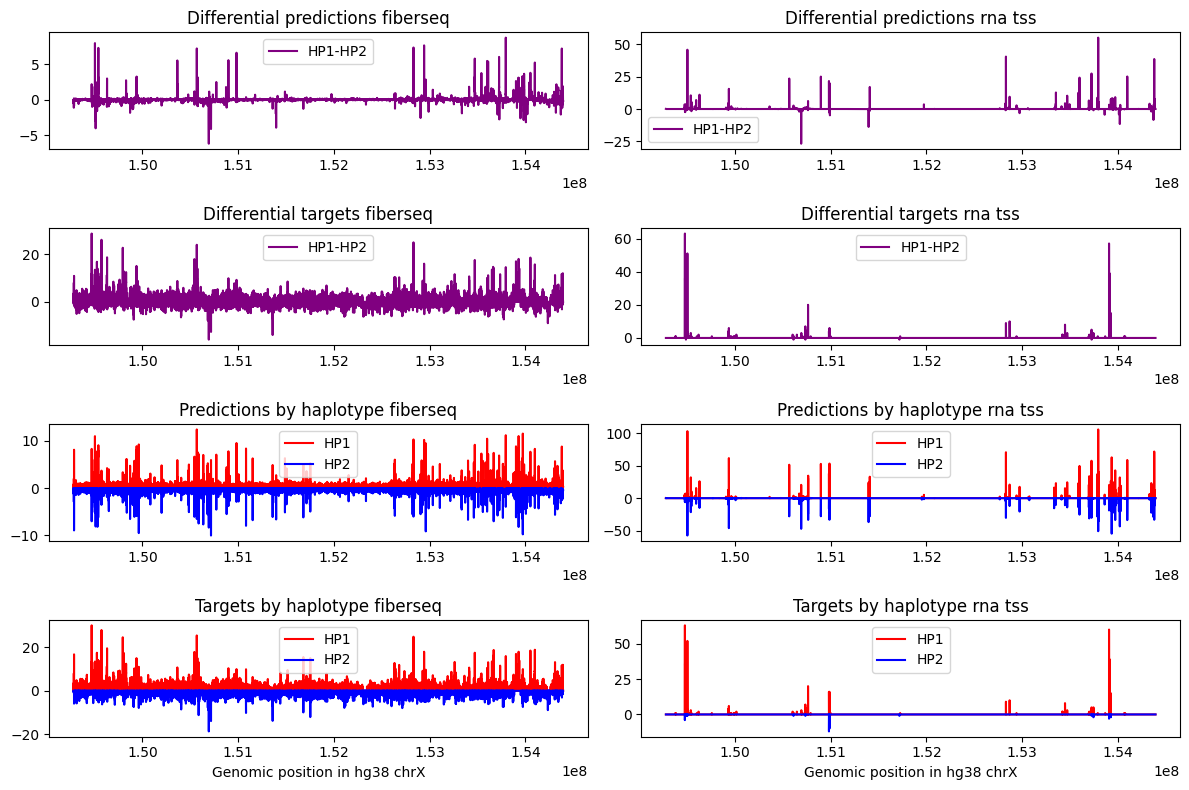

In [6]:
chromosome = "chrX"
# start = 131_500_000 - 196608*1
# end = 132_024_288 + 196_608*1
# chromosome = "chr13"
# start = 35_480_000 - (524288//2)
# end = start + 524288
start = 149_313_638 - 196608
end = start + 524288 + 196608*25
window_predictions_hp1 = predictor.predict_tiled_locus(
    chromosome=chromosome,
    start=start,
    end=end,
    step=196_608,
    chunk_length=524_288,
    sequence_path=hg38_fasta_file,
    methylation_paths=gm_hp1_methylation_files,
    target_paths=(
        gm_hp1_fiber_files,
        gm_hp1_rna_files,
    ),
    channel_subset=(63,64),
    methylation_load_kwargs = {
        'extend_cpg_sites':True,
        'cpg_values_rescale':0.01,
    },   
)
window_predictions_hp2 = predictor.predict_tiled_locus(
    chromosome=chromosome,
    start=start,
    end=end,
    step=196_608,
    chunk_length=524_288,
    sequence_path=hg38_fasta_file,
    methylation_paths=gm_hp2_methylation_files,
    target_paths=(
        gm_hp2_fiber_files,
        gm_hp2_rna_files,
    ),
    channel_subset=(63,64),
    methylation_load_kwargs = {
        'extend_cpg_sites':True,
        'cpg_values_rescale':0.01,
    },   
)
for key, value in window_predictions_hp1.items():
    print(f"HP1 {key}: {value.shape if isinstance(value, torch.Tensor) else type(value)}")
fig, axs = plt.subplots(4,2, figsize=(12,8))
for channel, name, target_scale in (0,'fiberseq', 2),(1,'rna tss', 128):
    xrange = predictor.model.crop_targets(np.arange(start, end, predictor.model.total_stride))
    axs[0,channel].plot(
        xrange,
        window_predictions_hp1["predictions"][0,channel,:]-window_predictions_hp2["predictions"][0,channel,:],
        label="HP1-HP2",
        color="purple",
    )
    axs[0,channel].set_title(f"Differential predictions {name}")
    axs[0,channel].legend()
    axs[1,channel].plot(
        xrange,
        target_scale*window_predictions_hp1["targets"][0,channel,:]-target_scale*window_predictions_hp2["targets"][0,channel,:],
        label="HP1-HP2",
        color="purple",
    )
    axs[1,channel].set_title(f"Differential targets {name}")
    axs[1,channel].legend()
    axs[2,channel].plot(
        xrange,
        window_predictions_hp1["predictions"][0,channel,:],
        label="HP1",
        color="red",
    )
    axs[2,channel].plot(
        xrange,
        -window_predictions_hp2["predictions"][0,channel,:],
        label="HP2",
        color="blue",
    )
    axs[2,channel].set_title(f"Predictions by haplotype {name}")
    axs[3,channel].plot(
        xrange,
        target_scale*window_predictions_hp1["targets"][0,channel,:],
        label="HP1",
        color="red",
    )
    axs[3,channel].plot(
        xrange,
        -target_scale*window_predictions_hp2["targets"][0,channel,:],
        label="HP2",
        color="blue",
    )
    axs[3,channel].set_title(f"Targets by haplotype {name}")
    axs[3,channel].set_xlabel(f"Genomic position in hg38 {chromosome}")
    axs[2,channel].legend()
    axs[3,channel].legend()
fig.tight_layout()

HP1 predictions: torch.Size([1, 2, 1536])
HP1 cpg_density: torch.Size([1, 1536])
HP1 conditioning_state: torch.Size([1, 1, 3, 524288])
HP1 conditional_seq_rep: torch.Size([1, 512, 1536])
HP1 true_conditioning_state_rep: torch.Size([1, 1, 1, 1536])
HP1 imputed_conditioning_state_rep: torch.Size([1, 43, 1, 1536])
HP1 sequence_attributions: torch.Size([1, 4, 524288])
HP1 conditioning_state_attributions: torch.Size([1, 1, 3, 524288])
HP1 targets: torch.Size([1, 2, 1536])
HP1 specifier: <class 'str'>
HP1 output_coordinates: torch.Size([1536])
HP1 input_coordinates: torch.Size([524288])


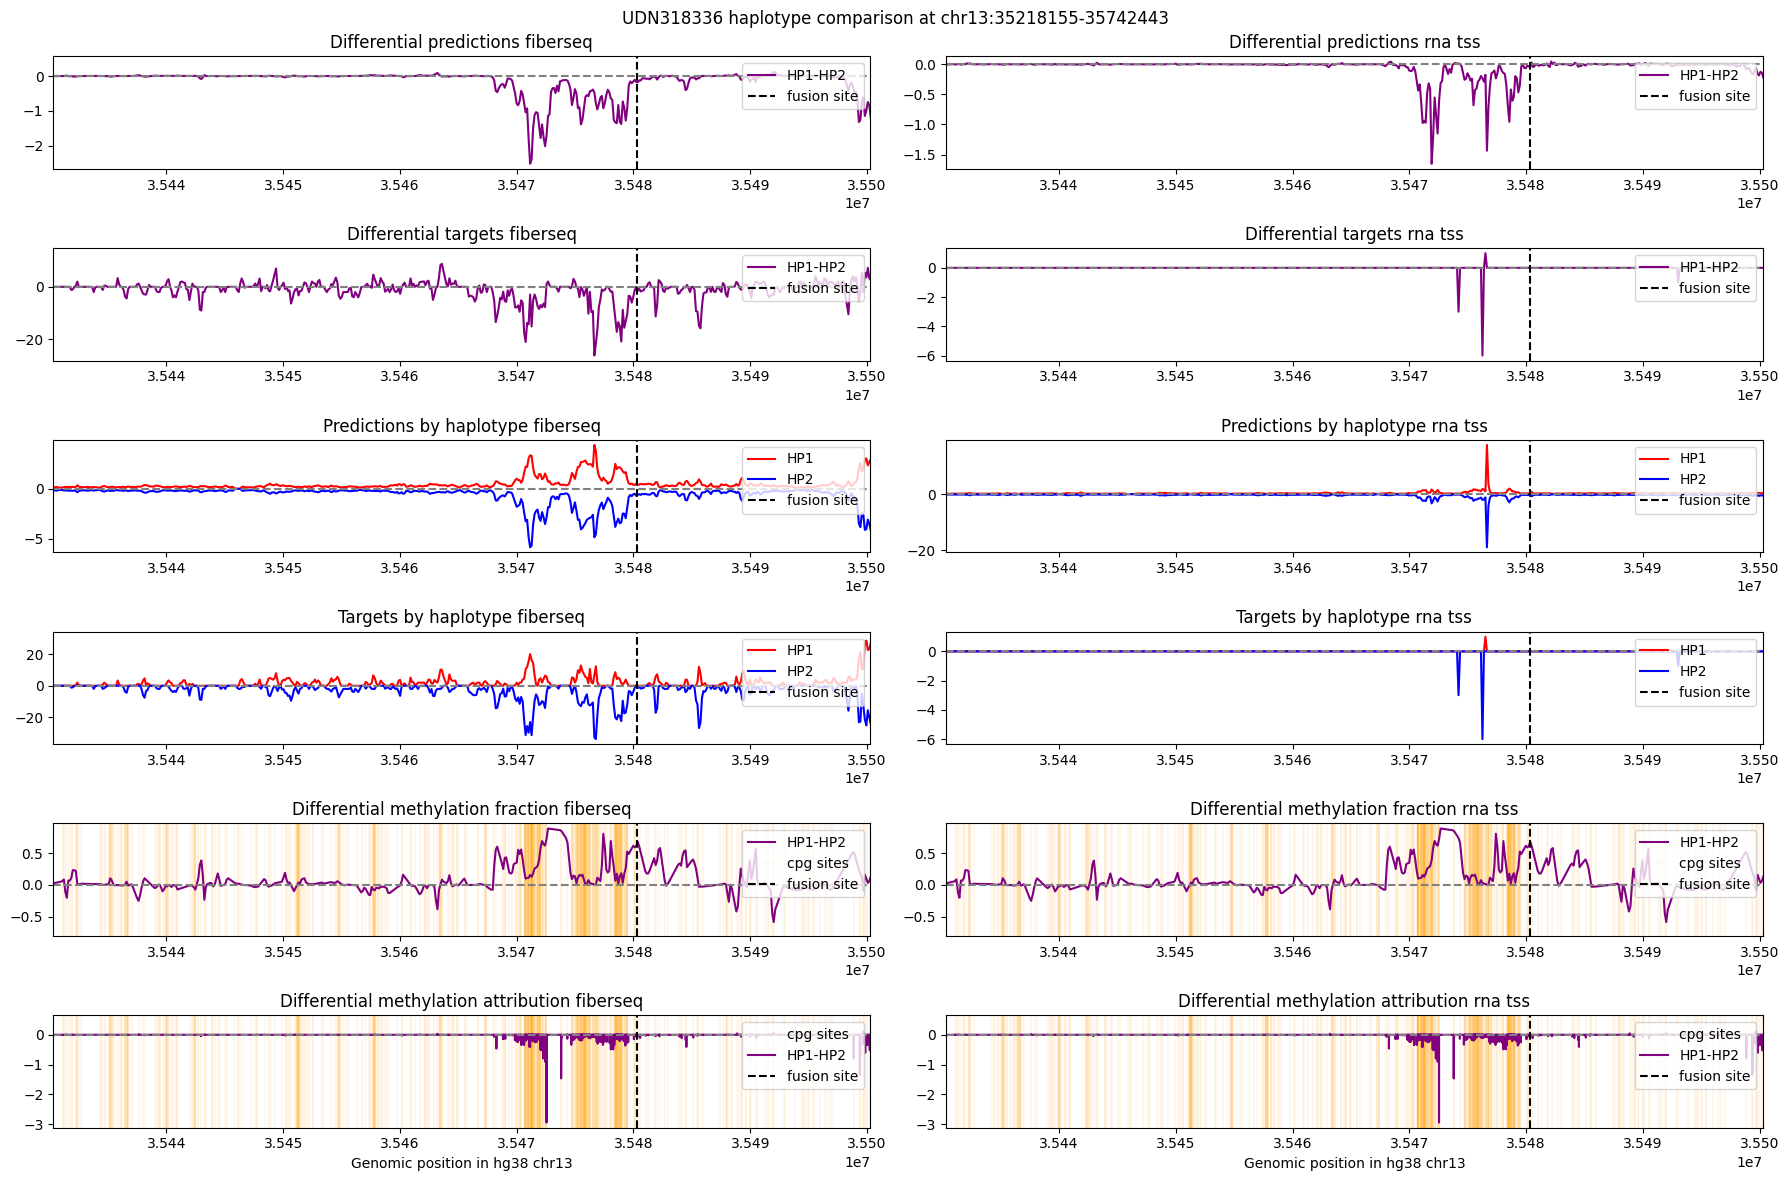

In [22]:
# chromosome = "chrX"
# start = 131_500_000 - 196608*8
# end = 132_024_288 + 196_608*8
chromosome = "chr13"
# start = 35_480_000 - 524288
# end = start + 524288 + 196608*3
start = 35480299 - 524288//2
end = start + 524288
fusion_point = 35480299
# start = 149_313_638 - 196608
# end = start + 524288 + 196608*25
window_predictions_hp1 = predictor.predict_locus(
    chromosome=chromosome,
    start=start,
    end=end,
    # step=196_608,
    # chunk_length=524_288,
    sequence_path=hg38_fasta_file,
    methylation_paths=udn_hp1_methylation_files,
    target_paths=(
        udn_hp1_fiber_files,
        udn_hp1_rna_files,
    ),
    channel_subset=(46,47),
    methylation_load_kwargs = {
        'extend_cpg_sites':True,
        'cpg_values_rescale':0.01,
    }, 
    capture_attributions = True,
    attribution_class = IntegratedGradients,
    attribution_peak_kwargs = {"peak_threshold":None,"min_peak_distance_bins":5},
    attribution_baseline_kwargs = dict(
        attribution_baseline_transform=InsertSyntheticCpG(center_window_size=-1, center_cpg_frac=0.95),
        attribution_baselines_per_sample=1),
    attribution_kwargs = dict(n_steps=5,internal_batch_size=1)  
)
window_predictions_hp2 = predictor.predict_locus(
    chromosome=chromosome,
    start=start,
    end=end,
    # step=196_608,
    # chunk_length=524_288,
    sequence_path=hg38_fasta_file,
    methylation_paths=udn_hp2_methylation_files,
    target_paths=(
        udn_hp2_fiber_files,
        udn_hp2_rna_files,
    ),
    channel_subset=(46,47),
    methylation_load_kwargs = {
        'extend_cpg_sites':True,
        'cpg_values_rescale':0.01,
    },   
    capture_attributions = True,
    attribution_class = IntegratedGradients,
    attribution_peak_kwargs = {"peak_threshold":None,"min_peak_distance_bins":5},
    attribution_baseline_kwargs = dict(
        attribution_baseline_transform=InsertSyntheticCpG(center_window_size=-1, center_cpg_frac=0.95),
        attribution_baselines_per_sample=1),
    attribution_kwargs = dict(n_steps=5,internal_batch_size=1)
)
for key, value in window_predictions_hp1.items():
    print(f"HP1 {key}: {value.shape if isinstance(value, torch.Tensor) else type(value)}")
fig, axs = plt.subplots(6,2, figsize=(18,12))
fig.suptitle(f"UDN318336 haplotype comparison at {chromosome}:{start}-{end}")

cpg_sites_bool = window_predictions_hp1["conditioning_state"][0,0,2,:]>0

for channel, name, target_scale in (0,'fiberseq', 2),(1,'rna tss', 128):
    xrange = window_predictions_hp1["output_coordinates"]
    axs[0,channel].plot(
        xrange,
        window_predictions_hp1["predictions"][0,channel,:]-window_predictions_hp2["predictions"][0,channel,:],
        label="HP1-HP2",
        color="purple",
    )
    axs[0,channel].set_title(f"Differential predictions {name}")
    axs[1,channel].plot(
        xrange,
        target_scale*window_predictions_hp1["targets"][0,channel,:]-target_scale*window_predictions_hp2["targets"][0,channel,:],
        label="HP1-HP2",
        color="purple",
    )
    axs[1,channel].set_title(f"Differential targets {name}")
    axs[2,channel].plot(
        xrange,
        window_predictions_hp1["predictions"][0,channel,:],
        label="HP1",
        color="red",
    )
    axs[2,channel].plot(
        xrange,
        -window_predictions_hp2["predictions"][0,channel,:],
        label="HP2",
        color="blue",
    )
    axs[2,channel].set_title(f"Predictions by haplotype {name}")
    axs[3,channel].plot(
        xrange,
        target_scale*window_predictions_hp1["targets"][0,channel,:],
        label="HP1",
        color="red",
    )
    axs[3,channel].plot(
        xrange,
        -target_scale*window_predictions_hp2["targets"][0,channel,:],
        label="HP2",
        color="blue",
    )
    axs[3,channel].set_title(f"Targets by haplotype {name}")
    axs[-1,channel].set_xlabel(f"Genomic position in hg38 {chromosome}")
    axs[4,channel].plot(
        window_predictions_hp1["output_coordinates"],
        window_predictions_hp1["true_conditioning_state_rep"][0,0,0:2,:].sum(dim=0).numpy()
        -window_predictions_hp2["true_conditioning_state_rep"][0,0,0:2,:].sum(dim=0).numpy(),
        label="HP1-HP2",
        color = "purple",
    )
    for mark_with_cpgs in [4, 5]:
        labelled=False
        for cpg_site, coord in zip(cpg_sites_bool, window_predictions_hp1["input_coordinates"]):
            if cpg_site:
                if labelled:
                    label="_nolabel"
                else:
                    label='cpg sites'
                    labelled=True
                axs[mark_with_cpgs,channel].axvline(x=coord, color='orange', linestyle='-', alpha=0.2, linewidth=.25, label=label, zorder=1)
    axs[4,channel].set_title(f"Differential methylation fraction {name}")
    axs[5,channel].plot(
        window_predictions_hp1["input_coordinates"],
        window_predictions_hp1["conditioning_state_attributions"][0,0,0:2,:].sum(dim=0).numpy()
        -window_predictions_hp2["conditioning_state_attributions"][0,0,0:2,:].sum(dim=0).numpy(),
        label="HP1-HP2",
        color = "purple",
    )
    axs[5,channel].set_title(f"Differential methylation attribution {name}")
    for ax in axs[:, channel]:
        ax.axvline(x=fusion_point, color='black', linestyle='--', label='fusion site')
        ax.axhline(y=0, color='gray', linestyle='--')
        ax.set_xlim(fusion_point - 50000, fusion_point + 20000)
        ax.legend(
            loc='upper right',
        )
fig.tight_layout()

Predicting chrX:24273698-24797986 in tiles:   0%|          | 0/1 [00:00<?, ?it/s]

Predicting chrX:24273698-24797986 in tiles:   0%|          | 0/1 [00:00<?, ?it/s]

HP1 predictions: torch.Size([1, 2, 1536])
HP1 cpg_density: torch.Size([1, 1536])
HP1 true_conditioning_state_rep: torch.Size([1, 1, 1, 1536])
HP1 imputed_conditioning_state_rep: torch.Size([1, 43, 1, 1536])
HP1 targets: torch.Size([1, 2, 1536])
HP1 specifier: <class 'str'>


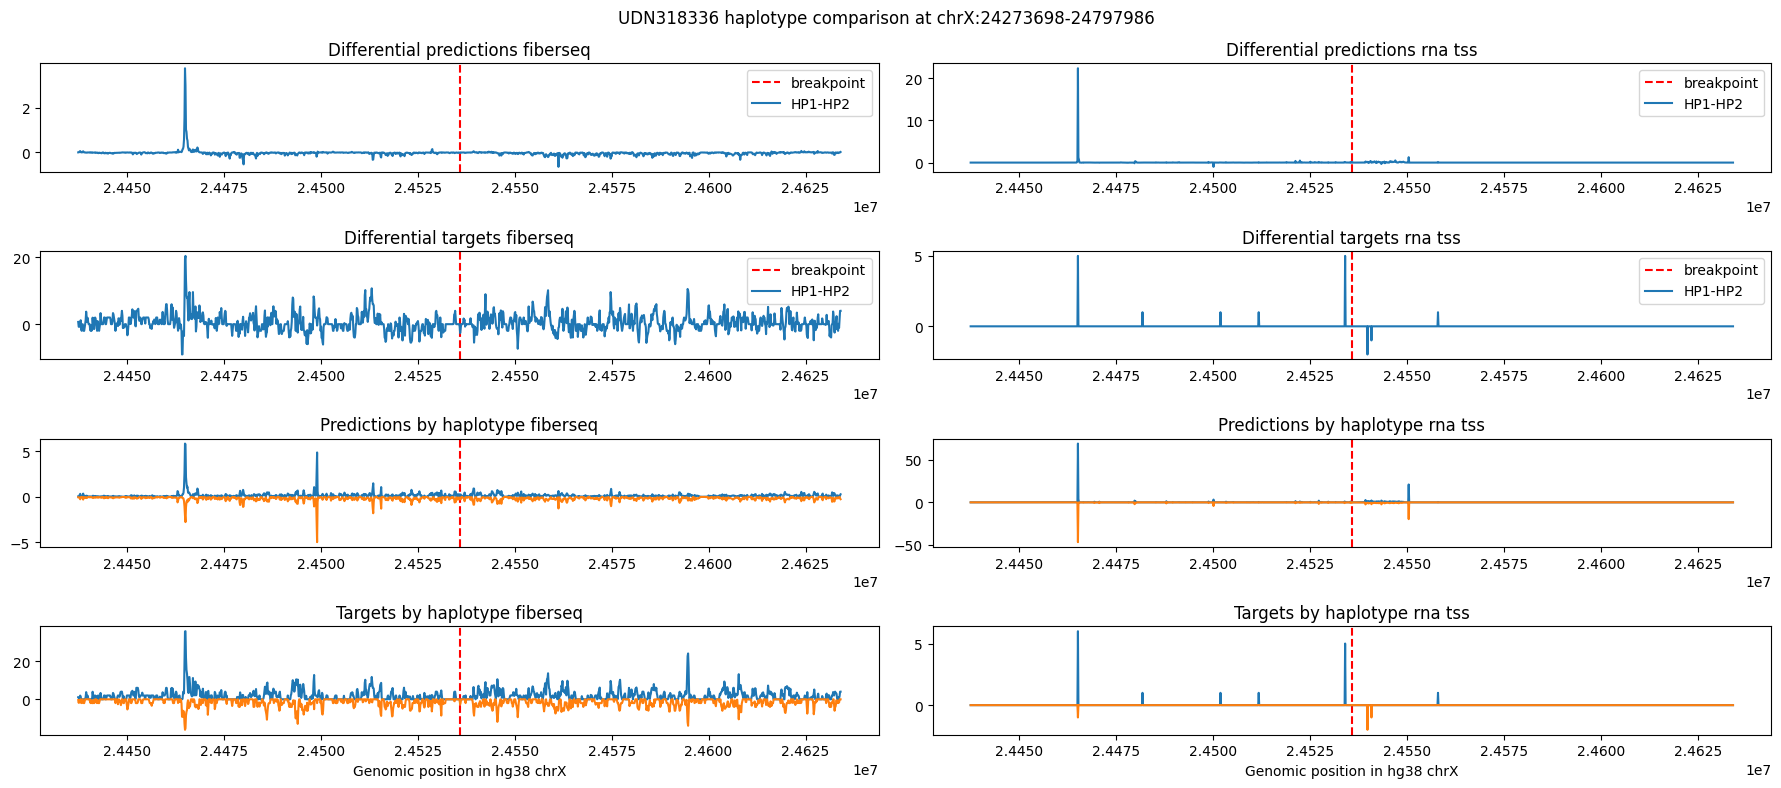

In [ ]:
# chromosome = "chrX"
# start = 131_500_000 - 196608*8
# end = 132_024_288 + 196_608*8
chromosome = "chrX"
# start = 24_530_000 - 524288
# end = start + 524288 + 196608*6
start = 24_535_842 - 524288//2
end = start + 524288
# start = 149_313_638 - 196608
# end = start + 524288 + 196608*25
window_predictions_hp1 = predictor.predict_tiled_locus(
    chromosome=chromosome,
    start=start,
    end=end,
    step=196_608,
    chunk_length=524_288,
    sequence_path=fasta_file,
    methylation_paths=udn_hp1_methylation_files,
    target_paths=(
        udn_hp1_fiber_files,
        udn_hp1_rna_files,
    ),
    channel_subset=(63,64),
    methylation_load_kwargs = {
        'extend_cpg_sites':True,
        'cpg_values_rescale':0.01,
    },   
    capture_attributions = True,
    attribution_class = IntegratedGradients,
    attribution_peak_kwargs = {"peak_threshold":None,"min_peak_distance_bins":5},
    attribution_baseline_kwargs = dict(
        attribution_baseline_transform=InsertSyntheticCpG(center_window_size=-1, center_cpg_frac=0.95),
        attribution_baselines_per_sample=1),
    attribution_kwargs = dict(n_steps=5,internal_batch_size=1)
)
window_predictions_hp2 = predictor.predict_tiled_locus(
    chromosome=chromosome,
    start=start,
    end=end,
    step=196_608,
    chunk_length=524_288,
    sequence_path=fasta_file,
    methylation_paths=udn_hp2_methylation_files,
    target_paths=(
        udn_hp2_fiber_files,
        udn_hp2_rna_files,
    ),
    channel_subset=(63,64),
    methylation_load_kwargs = {
        'extend_cpg_sites':True,
        'cpg_values_rescale':0.01,
    },   
    capture_attributions = True,
    attribution_class = IntegratedGradients,
    attribution_peak_kwargs = {"peak_threshold":None,"min_peak_distance_bins":5},
    attribution_baseline_kwargs = dict(
        attribution_baseline_transform=InsertSyntheticCpG(center_window_size=-1, center_cpg_frac=0.95),
        attribution_baselines_per_sample=1),
    attribution_kwargs = dict(n_steps=5,internal_batch_size=1)
)
for key, value in window_predictions_hp1.items():
    print(f"HP1 {key}: {value.shape if isinstance(value, torch.Tensor) else type(value)}")
fig, axs = plt.subplots(4,2, figsize=(18,8))
fig.suptitle(f"UDN318336 haplotype comparison at {chromosome}:{start}-{end}")
for channel, name, target_scale in (0,'fiberseq', 2),(1,'rna tss', 128):
    for ax in axs[:, channel]:
        ax.axvline(x=24_535_842, color='red', linestyle='--', label='breakpoint')
    xrange = predictor.model.crop_targets(np.arange(start, end, predictor.model.total_stride))
    axs[0,channel].plot(
        xrange,
        window_predictions_hp1["predictions"][0,channel,:]-window_predictions_hp2["predictions"][0,channel,:],
        label="HP1-HP2",
    )
    axs[0,channel].set_title(f"Differential predictions {name}")
    axs[0,channel].legend()
    axs[1,channel].plot(
        xrange,
        target_scale*window_predictions_hp1["targets"][0,channel,:]-target_scale*window_predictions_hp2["targets"][0,channel,:],
        label="HP1-HP2",
    )
    axs[1,channel].set_title(f"Differential targets {name}")
    axs[1,channel].legend()
    axs[2,channel].plot(
        xrange,
        window_predictions_hp1["predictions"][0,channel,:],
        label="HP1",
    )
    axs[2,channel].plot(
        xrange,
        -window_predictions_hp2["predictions"][0,channel,:],
        label="HP2",
    )
    axs[2,channel].set_title(f"Predictions by haplotype {name}")
    axs[3,channel].plot(
        xrange,
        target_scale*window_predictions_hp1["targets"][0,channel,:],
        label="HP1",
    )
    axs[3,channel].plot(
        xrange,
        -target_scale*window_predictions_hp2["targets"][0,channel,:],
        label="HP2",
    )
    axs[3,channel].set_title(f"Targets by haplotype {name}")
    axs[3,channel].set_xlabel(f"Genomic position in hg38 {chromosome}")
fig.tight_layout()

In [ ]:
# chromosome = "chrX"
# start = 0
# end = 155_648_000
# hp1_chrX_dict = predictor.predict_tiled_locus(
#     chromosome=chromosome,
#     start=start,
#     end=end,
#     step=196608,
#     chunk_length=524288,
#     sequence_path=fasta_file,
#     methylation_paths=udn_hp1_methylation_files,
#     target_paths=(
#         udn_hp1_fiber_files,
#         udn_hp1_rna_files,
#     ),
#     channel_subset = (63,64),
#     methylation_load_kwargs = {
#         'extend_cpg_sites':True,
#         'cpg_values_rescale':0.01,
#     },   
# )
# torch.save(hp1_chrX_dict, "/global/scratch/projects/vector_streetslab/oberon/methylseqnet_manuscript_datasets/pickles/udn_hp1_chrX_fiber-rna.pt")
# hp2_chrX_dict = predictor.predict_tiled_locus(
#     chromosome=chromosome,
#     start=0,
#     end=155_648_000,
#     step=196608,
#     chunk_length=524288,
#     sequence_path=fasta_file,
#     methylation_paths=udn_hp2_methylation_files,
#     target_paths=(
#         udn_hp2_fiber_files,
#         udn_hp2_rna_files,
#     ),
#     channel_subset = (63,64),
#     methylation_load_kwargs = {
#         'extend_cpg_sites':True,
#         'cpg_values_rescale':0.01,
#     },   
# )
# torch.save(hp2_chrX_dict, "/global/scratch/projects/vector_streetslab/oberon/methylseqnet_manuscript_datasets/pickles/udn_hp2_chrX_fiber-rna.pt")
# chromosome = "chr13"
# start = 0
# end = 114_364_328 - 4_008
# hp1_chr13_dict = predictor.predict_tiled_locus(
#     chromosome=chromosome,
#     start=start,
#     end=end,
#     step=196608,
#     chunk_length=524288,
#     sequence_path=fasta_file,
#     methylation_paths=udn_hp1_methylation_files,
#     target_paths=(
#         udn_hp1_fiber_files,
#         udn_hp1_rna_files,
#     ),
#     channel_subset = (63,64),
#     methylation_load_kwargs = {
#         'extend_cpg_sites':True,
#         'cpg_values_rescale':0.01,
#     },   
# )
# torch.save(hp1_chr13_dict, "/global/scratch/projects/vector_streetslab/oberon/methylseqnet_manuscript_datasets/pickles/udn_hp1_chr13_fiber-rna.pt")
# hp2_chr13_dict = predictor.predict_tiled_locus(
#     chromosome=chromosome,
#     start=0,
#     end=end,
#     step=196608,
#     chunk_length=524288,
#     sequence_path=fasta_file,
#     methylation_paths=udn_hp2_methylation_files,
#     target_paths=(
#         udn_hp2_fiber_files,
#         udn_hp2_rna_files,
#     ),
#     channel_subset = (63,64),
#     methylation_load_kwargs = {
#         'extend_cpg_sites':True,
#         'cpg_values_rescale':0.01,
#     },   
# )
# torch.save(hp2_chr13_dict, "/global/scratch/projects/vector_streetslab/oberon/methylseqnet_manuscript_datasets/pickles/udn_hp2_chr13_fiber-rna.pt")

Predicting chrX:0-155648000 in tiles:   0%|          | 0/790 [00:00<?, ?it/s]

Predicting chrX:0-155648000 in tiles:   0%|          | 0/790 [00:00<?, ?it/s]

In [10]:
# torch.save(hp2_dict, "/global/scratch/projects/vector_streetslab/oberon/methylseqnet_manuscript_datasets/pickles/udn_hp2_atac.pt")
hp1_chrX_dict = torch.load("/global/scratch/projects/vector_streetslab/oberon/methylseqnet_manuscript_datasets/pickles/udn_hp1_chrX_fiber-rna.pt")
hp2_chrX_dict = torch.load("/global/scratch/projects/vector_streetslab/oberon/methylseqnet_manuscript_datasets/pickles/udn_hp2_chrX_fiber-rna.pt")
hp1_chr13_dict = torch.load("/global/scratch/projects/vector_streetslab/oberon/methylseqnet_manuscript_datasets/pickles/udn_hp1_chr13_fiber-rna.pt")
hp2_chr13_dict = torch.load("/global/scratch/projects/vector_streetslab/oberon/methylseqnet_manuscript_datasets/pickles/udn_hp2_chr13_fiber-rna.pt")
for key, value in hp1_chrX_dict.items():
    print(f"{key}: {value.shape if isinstance(value, torch.Tensor) else value}")

predictions: torch.Size([1, 2, 1213440])
cpg_density: torch.Size([1, 1213440])
true_conditioning_state_rep: torch.Size([1, 1, 1, 1213440])
imputed_conditioning_state_rep: torch.Size([1, 43, 1, 1213440])
targets: torch.Size([1, 2, 1213440])
output_coordinates: torch.Size([1213440])
specifier: chrX:0-155648000|(63, 64)


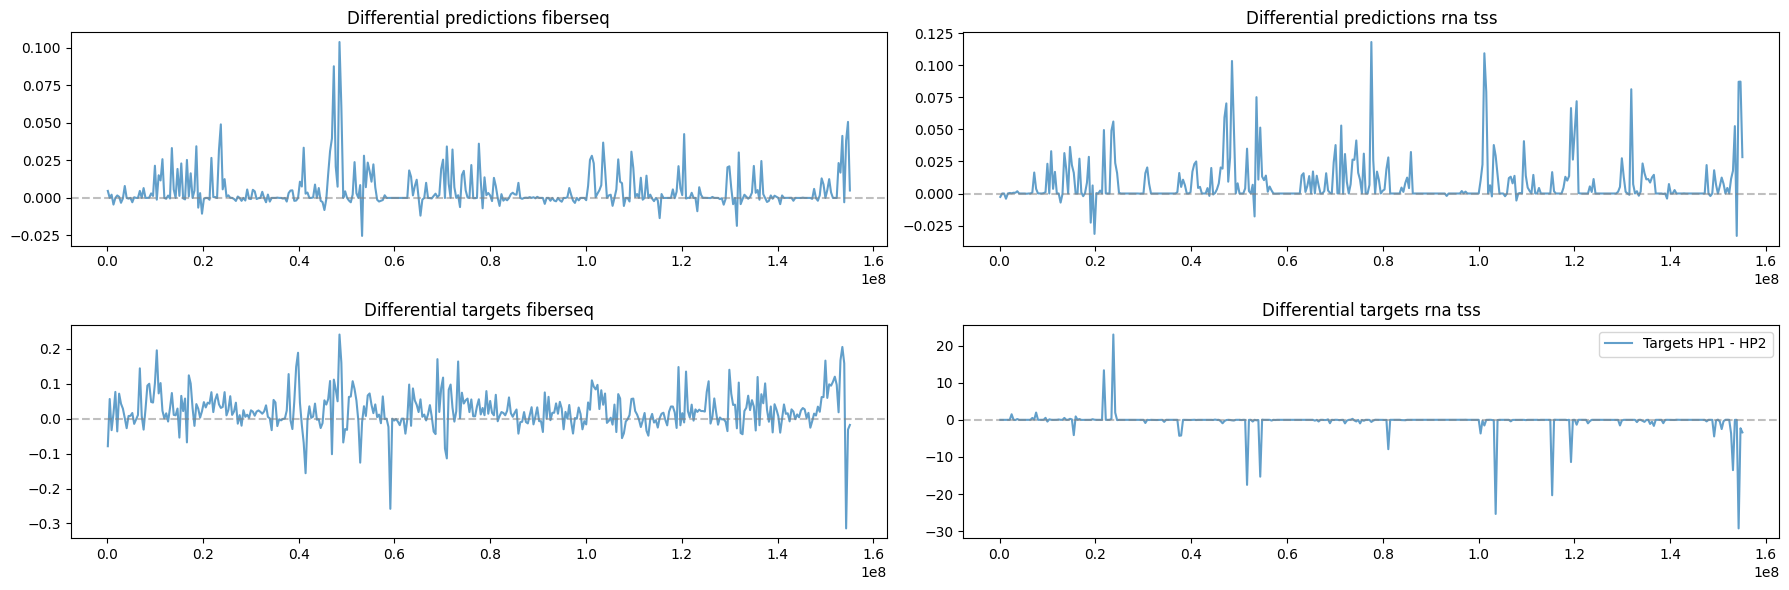

In [17]:
avg_bins = 3072
cutoff_cts = 5

fig, axs = plt.subplots(2,2,figsize=(18,6))

for channel, name, target_scale in (0,'fiberseq', 1),(1,'rna tss', 2048):
    xrange = hp1_chrX_dict["output_coordinates"][::avg_bins]

    hp1_predictions_slice = 2*hp1_chrX_dict["predictions"][0, channel, :]
    hp1_predictions_slice = hp1_predictions_slice * (hp1_predictions_slice > cutoff_cts)
    hp1_predictions_reshaped = hp1_predictions_slice.reshape(-1, avg_bins).mean(axis=1)
    hp1_targets_slice = target_scale*hp1_chrX_dict["targets"][0, channel, :]
    hp1_targets_slice = hp1_targets_slice * (hp1_targets_slice>cutoff_cts) # zero out very low values to reduce noise in the plot
    hp1_targets_reshaped = hp1_targets_slice.reshape(-1, avg_bins).mean(axis=1)

    hp2_predictions_slice = 2*hp2_chrX_dict["predictions"][0, channel, :]
    hp2_predictions_slice = hp2_predictions_slice * (hp2_predictions_slice > cutoff_cts)
    hp2_predictions_reshaped = hp2_predictions_slice.reshape(-1, avg_bins).mean(axis=1)
    hp2_targets_slice = target_scale*hp2_chrX_dict["targets"][0, channel, :]
    hp2_targets_slice = hp2_targets_slice * (hp2_targets_slice>cutoff_cts) # zero out very low values to reduce noise in the plot
    hp2_targets_reshaped = hp2_targets_slice.reshape(-1, avg_bins).mean(axis=1)

    # plt.plot(hp1_predictions_reshaped,label="Predictions HP1")
    # plt.plot(-hp1_targets_reshaped,label="Targets HP1",alpha=0.25)

    # plt.plot(hp2_predictions_reshaped,label="Predictions HP2")
    # plt.plot(-hp2_targets_reshaped,label="Targets HP2",alpha=0.25)
    axs[0, channel].plot(xrange,hp1_predictions_reshaped - hp2_predictions_reshaped,alpha=0.7,label="Predictions HP1 - HP2")
    axs[0, channel].axhline(0, color='gray', linestyle='--', alpha=0.5)
    axs[0, channel].set_title(f"Differential predictions {name}")
    axs[1, channel].plot(xrange,hp1_targets_reshaped - hp2_targets_reshaped,alpha=0.7,label="Targets HP1 - HP2")
    axs[1, channel].axhline(0, color='gray', linestyle='--', alpha=0.5)
    axs[1, channel].set_title(f"Differential targets {name}")
plt.tight_layout()
plt.legend()
plt.show()

total sites passing activity cutoff chr13/chrX: 2484 3120


/tmp/ipykernel_445132/3584275702.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=predictions_df, x="group", y="value", cut=0, inner="quartile", palette=palette, ax=axs[0, 0])
/tmp/ipykernel_445132/3584275702.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=targets_df, x="group", y="value", cut=0, inner="quartile", palette=palette, ax=axs[0, 1])
/tmp/ipykernel_445132/3584275702.py:76: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(data=predictions_df, x="group", y="value", ci=68, palette=palette, ax=axs[1, 0])
/tmp/ipykernel_445132/3584275702.py:76: FutureWarning: 

Passing `palette` without assigning

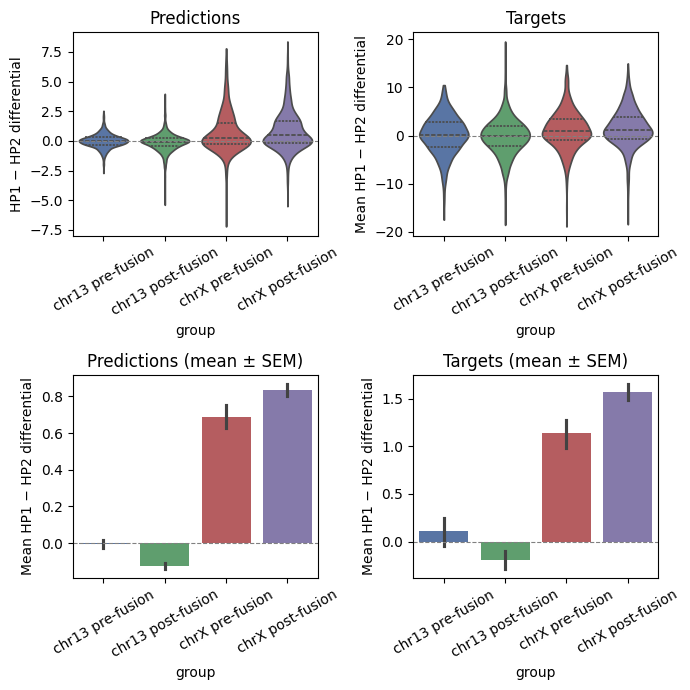

In [76]:
fusion_site_chrX = 24_535_842
fusion_site_chr13 = 35_480_299

chr13_pre_fusion_mask = hp1_chr13_dict["output_coordinates"] < fusion_site_chr13
chr13_post_fusion_mask = hp1_chr13_dict["output_coordinates"] >= fusion_site_chr13
chrX_pre_fusion_mask = hp1_chrX_dict["output_coordinates"] < fusion_site_chrX
chrX_post_fusion_mask = hp1_chrX_dict["output_coordinates"] >= fusion_site_chrX

cutoff_cts = 2
cutoff_on = "predictions"
chr13_either_active_mask = (hp1_chr13_dict[cutoff_on][0,0,:]>=cutoff_cts) | (hp2_chr13_dict[cutoff_on][0,0,:]>=cutoff_cts)
chrX_either_active_mask = (hp1_chrX_dict[cutoff_on][0,0,:]>=cutoff_cts) | (hp2_chrX_dict[cutoff_on][0,0,:]>=cutoff_cts)

print("total sites passing activity cutoff chr13/chrX:", chr13_either_active_mask.sum().item(), chrX_either_active_mask.sum().item())

chr13_pre_fusion_differential = hp1_chr13_dict["predictions"][0,0,chr13_pre_fusion_mask & chr13_either_active_mask] - hp2_chr13_dict["predictions"][0,0,chr13_pre_fusion_mask & chr13_either_active_mask]
chr13_post_fusion_differential = hp1_chr13_dict["predictions"][0,0,chr13_post_fusion_mask & chr13_either_active_mask] - hp2_chr13_dict["predictions"][0,0,chr13_post_fusion_mask & chr13_either_active_mask]
chrX_pre_fusion_differential = hp1_chrX_dict["predictions"][0,0,chrX_pre_fusion_mask & chrX_either_active_mask] - hp2_chrX_dict["predictions"][0,0,chrX_pre_fusion_mask & chrX_either_active_mask]
chrX_post_fusion_differential = hp1_chrX_dict["predictions"][0,0,chrX_post_fusion_mask & chrX_either_active_mask] - hp2_chrX_dict["predictions"][0,0,chrX_post_fusion_mask & chrX_either_active_mask]

chr13_pre_fusion_differential_targets = hp1_chr13_dict["targets"][0,0,chr13_pre_fusion_mask & chr13_either_active_mask] - hp2_chr13_dict["targets"][0,0,chr13_pre_fusion_mask & chr13_either_active_mask]
chr13_post_fusion_differential_targets = hp1_chr13_dict["targets"][0,0,chr13_post_fusion_mask & chr13_either_active_mask] - hp2_chr13_dict["targets"][0,0,chr13_post_fusion_mask & chr13_either_active_mask]
chrX_pre_fusion_differential_targets = hp1_chrX_dict["targets"][0,0,chrX_pre_fusion_mask & chrX_either_active_mask] - hp2_chrX_dict["targets"][0,0,chrX_pre_fusion_mask & chrX_either_active_mask]
chrX_post_fusion_differential_targets = hp1_chrX_dict["targets"][0,0,chrX_post_fusion_mask & chrX_either_active_mask] - hp2_chrX_dict["targets"][0,0,chrX_post_fusion_mask & chrX_either_active_mask]

predictions_df = pd.DataFrame({
    "value": np.concatenate([
        chr13_pre_fusion_differential,
        chr13_post_fusion_differential,
        chrX_pre_fusion_differential,
        chrX_post_fusion_differential,
    ]),
    "group": (
        ["chr13 pre-fusion"] * len(chr13_pre_fusion_differential) +
        ["chr13 post-fusion"] * len(chr13_post_fusion_differential) +
        ["chrX pre-fusion"] * len(chrX_pre_fusion_differential) +
        ["chrX post-fusion"] * len(chrX_post_fusion_differential)
    ),
})
targets_df = pd.DataFrame({
    "value": np.concatenate([
        chr13_pre_fusion_differential_targets,
        chr13_post_fusion_differential_targets,
        chrX_pre_fusion_differential_targets,
        chrX_post_fusion_differential_targets,
    ]),
    "group": (
        ["chr13 pre-fusion"] * len(chr13_pre_fusion_differential_targets) +
        ["chr13 post-fusion"] * len(chr13_post_fusion_differential_targets) +
        ["chrX pre-fusion"] * len(chrX_pre_fusion_differential_targets) +
        ["chrX post-fusion"] * len(chrX_post_fusion_differential_targets)
    ),
})

palette = {
    "chr13 pre-fusion": "#4C72B0",
    "chr13 post-fusion": "#55A868",
    "chrX pre-fusion": "#C44E52",
    "chrX post-fusion": "#8172B2",
}

fig, axs = plt.subplots(2, 2, figsize=(7, 7))

sns.violinplot(data=predictions_df, x="group", y="value", cut=0, inner="quartile", palette=palette, ax=axs[0, 0])
axs[0, 0].set_ylabel("HP1 − HP2 differential")
axs[0, 0].axhline(0, color="grey", linestyle="--", linewidth=0.8)
axs[0, 0].set_title("Predictions")
axs[0, 0].tick_params(axis='x', rotation=30)

sns.violinplot(data=targets_df, x="group", y="value", cut=0, inner="quartile", palette=palette, ax=axs[0, 1])
axs[0, 1].set_ylabel("Mean HP1 − HP2 differential")
axs[0, 1].axhline(0, color="grey", linestyle="--", linewidth=0.8)
axs[0, 1].set_title("Targets")
axs[0, 1].tick_params(axis='x', rotation=30)

sns.barplot(data=predictions_df, x="group", y="value", ci=68, palette=palette, ax=axs[1, 0])
axs[1, 0].set_ylabel("Mean HP1 − HP2 differential")
axs[1, 0].axhline(0, color="grey", linestyle="--", linewidth=0.8)
axs[1, 0].set_title("Predictions (mean ± SEM)")
axs[1, 0].tick_params(axis='x', rotation=30)

sns.barplot(data=targets_df, x="group", y="value", ci=68, palette=palette, ax=axs[1, 1])
axs[1, 1].set_ylabel("Mean HP1 − HP2 differential")
axs[1, 1].axhline(0, color="grey", linestyle="--", linewidth=0.8)
axs[1, 1].set_title("Targets (mean ± SEM)")
axs[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [18]:
io_mappings_df = predictor.model.get_io_mappings_df()
print(io_mappings_df[io_mappings_df["methylation_files"].str.contains("Fibroblast")])
print(io_mappings_df[io_mappings_df["methylation_files"].str.contains("Neuron")])

   dataset_key  absolute_channel  absolute_cell_type  channel  cell_type  \
25       atlas                25                  17       25         17   
26       atlas                26                  17       26         17   

   data_type                                   genome      methylation_files  \
25  ATAC-seq  /mnt/faststorage/oberon/genomes/hg38.fa  ['Heart-Fibroblasts']   
26  CAGE-seq  /mnt/faststorage/oberon/genomes/hg38.fa  ['Heart-Fibroblasts']   

               label_files  
25  ['Cardiac Fibroblast']  
26           ['CNhs12498']  
   dataset_key  absolute_channel  absolute_cell_type  channel  cell_type  \
46       atlas                46                  29       46         29   
47       atlas                47                  29       47         29   

   data_type                                   genome methylation_files  \
46  ATAC-seq  /mnt/faststorage/oberon/genomes/hg38.fa        ['Neuron']   
47  CAGE-seq  /mnt/faststorage/oberon/genomes/hg38.fa        ['N

In [ ]:
# fusion_site_chrX = 24_535_842
# fusion_site_chr13 = 35_480_299

# tss_by_section = {}

# tss_by_section["pre_fusion_X"] = fetch_tss_from_gtf(
#     str(annotations / "gencode.v49.basic.annotation.sorted.gtf.gz"),
#     fetch_params=("chrX", 0 , fusion_site_chrX,),
#     # intervals=test_intervals,
# )
# tss_by_section["post_fusion_X"] = fetch_tss_from_gtf(
#     str(annotations / "gencode.v49.basic.annotation.sorted.gtf.gz"),
#     fetch_params=("chrX", fusion_site_chrX , 155_270_560,),
#     # intervals=test_intervals,
# )
# tss_by_section["pre_fusion_13"] = fetch_tss_from_gtf(
#     str(annotations / "gencode.v49.basic.annotation.sorted.gtf.gz"),
#     fetch_params=("chr13", 0 , fusion_site_chr13,),
#     # intervals=test_intervals,
# )
# tss_by_section["post_fusion_13"] = fetch_tss_from_gtf(
#     str(annotations / "gencode.v49.basic.annotation.sorted.gtf.gz"),
#     fetch_params=("chr13", fusion_site_chr13 , 114_364_328,),
#     # intervals=test_intervals,
# )

# udn_channels_dict = {
#     # "lymphoblast": (63,64),
#     "fibroblast": (25,26),
#     # "neuron": (46,47),
# }

# udn_cell_culture_dict = {
#     "fibroblast": (
#         udn_hp1_fibroblast_methylation_files,
#         udn_hp1_fibroblast_fiber_files,
#         udn_hp1_rna_files,
#         udn_hp2_fibroblast_methylation_files,
#         udn_hp2_fibroblast_fiber_files,
#         udn_hp2_rna_files,
#     ),
#     # "retinal_organoid": (
#     #     udn_hp1_methylation_files,
#     #     udn_hp1_fiber_files,
#     #     udn_hp1_rna_files,
#     #     udn_hp2_methylation_files,
#     #     udn_hp2_fiber_files,
#     #     udn_hp2_rna_files,
#     # ),
# }

# hp1_tss_rna_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
# hp1_tss_pred_rna_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
# hp2_tss_rna_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
# hp2_tss_pred_rna_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
# hp1_tss_fiber_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
# hp1_tss_pred_fiber_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
# hp2_tss_fiber_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))    
# hp2_tss_pred_fiber_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

# hp1_tss_methylation_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
# hp2_tss_methylation_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

# hp1_tss_conditional_rep_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
# hp2_tss_conditional_rep_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))


# bin_range = 5

# for cell_culture, (
#     hp1_meth,
#     hp1_fiber,
#     hp1_rna,
#     hp2_meth,
#     hp2_fiber,
#     hp2_rna,
# ) in udn_cell_culture_dict.items():
#     for section, tss_list in tss_by_section.items():
#         for tss_dict in tqdm(tss_list,desc=f"Predicting TSS in {section}", total=len(tss_list)):
#             chrom, tss = tss_dict["chrom"], tss_dict["tss"]
#             hp1_dict = predictor.predict_locus(
#                 chromosome=chrom,
#                 start=tss-524288//2,
#                 end=tss+524288//2,
#                 sequence_path=fasta_file_hp1,
#                 methylation_paths=hp1_meth,
#                 target_paths=(
#                     hp1_fiber,
#                     hp1_rna,
#                 ),
#                 channel_subset = None,
#                 methylation_load_kwargs = {
#                     'extend_cpg_sites':True,
#                     'cpg_values_rescale':0.01,
#                 },  
#             )
#             outputs_len = hp1_dict["output_coordinates"].shape[0]
#             hp2_dict = predictor.predict_locus(
#                 chromosome=chrom,
#                 start=tss-524288//2,
#                 end=tss+524288//2,
#                 sequence_path=fasta_file_hp2,
#                 methylation_paths=hp2_meth,
#                 target_paths=(
#                     hp2_fiber,
#                     hp2_rna,
#                 ),
#                 channel_subset = None,
#                 methylation_load_kwargs = {
#                     'extend_cpg_sites':True,
#                     'cpg_values_rescale':0.01,
#                 },  
#             )
#             outputs_len = hp2_dict["output_coordinates"].shape[0]
#             for celltype, channels in udn_channels_dict.items():
#                 hp1_tss_rna_by_section[cell_culture][celltype][section].append(hp1_dict["targets"][0,1,outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())
#                 hp1_tss_pred_rna_by_section[cell_culture][celltype][section].append(hp1_dict["predictions"][0,channels[1],outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())
#                 hp1_tss_fiber_by_section[cell_culture][celltype][section].append(hp1_dict["targets"][0,0,outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())
#                 hp1_tss_pred_fiber_by_section[cell_culture][celltype][section].append(hp1_dict["predictions"][0,channels[0],outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())
#                 hp2_tss_rna_by_section[cell_culture][celltype][section].append(hp2_dict["targets"][0,1,outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())
#                 hp2_tss_pred_rna_by_section[cell_culture][celltype][section].append(hp2_dict["predictions"][0,channels[1],outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())
#                 hp2_tss_fiber_by_section[cell_culture][celltype][section].append(hp2_dict["targets"][0,0,outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())
#                 hp2_tss_pred_fiber_by_section[cell_culture][celltype][section].append(hp2_dict["predictions"][0,channels[0],outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())

#                 hp1_tss_methylation_by_section[cell_culture][celltype][section].append(hp1_dict["true_conditioning_state_rep"][0,0,0,outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())
#                 hp2_tss_methylation_by_section[cell_culture][celltype][section].append(hp2_dict["true_conditioning_state_rep"][0,0,0,outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())

#                 hp1_tss_conditional_rep_by_section[cell_culture][celltype][section].append(hp1_dict["conditional_seq_rep"][0,:,outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())
#                 hp2_tss_conditional_rep_by_section[cell_culture][celltype][section].append(hp2_dict["conditional_seq_rep"][0,:,outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())

Predicting TSS in pre_fusion_X:   0%|          | 0/122 [00:00<?, ?it/s]

Predicting TSS in post_fusion_X:   0%|          | 0/729 [00:00<?, ?it/s]

Predicting TSS in pre_fusion_13:   0%|          | 0/82 [00:00<?, ?it/s]

Predicting TSS in post_fusion_13:   0%|          | 0/238 [00:00<?, ?it/s]

In [3]:
# all_dicts = {
#     "hp1_tss_rna_by_section": hp1_tss_rna_by_section,
#     "hp1_tss_pred_rna_by_section": hp1_tss_pred_rna_by_section,
#     "hp2_tss_rna_by_section": hp2_tss_rna_by_section,
#     "hp2_tss_pred_rna_by_section": hp2_tss_pred_rna_by_section,
#     "hp1_tss_fiber_by_section": hp1_tss_fiber_by_section,
#     "hp1_tss_pred_fiber_by_section": hp1_tss_pred_fiber_by_section,
#     "hp2_tss_fiber_by_section": hp2_tss_fiber_by_section,
#     "hp2_tss_pred_fiber_by_section": hp2_tss_pred_fiber_by_section,
#     "hp1_tss_methylation_by_section": hp1_tss_methylation_by_section,
#     "hp2_tss_methylation_by_section": hp2_tss_methylation_by_section,
#     "hp1_tss_conditional_rep_by_section": hp1_tss_conditional_rep_by_section,
#     "hp2_tss_conditional_rep_by_section": hp2_tss_conditional_rep_by_section,
# }

# # Convert nested defaultdicts to regular dicts
# all_dicts = {
#     name: {k1: {k2: dict(d2) for k2, d2 in d1.items()} for k1, d1 in d.items()}
#     for name, d in all_dicts.items()
# }

# with open("udn_tss_results.pkl", "wb") as f:
#     pickle.dump(all_dicts, f)

with open("udn_tss_results.pkl", "rb") as f:
    all_dicts = pickle.load(f)

(
    hp1_tss_rna_by_section,
    hp1_tss_pred_rna_by_section,
    hp2_tss_rna_by_section,
    hp2_tss_pred_rna_by_section,
    hp1_tss_fiber_by_section,
    hp1_tss_pred_fiber_by_section,
    hp2_tss_fiber_by_section,
    hp2_tss_pred_fiber_by_section,
    hp1_tss_methylation_by_section,
    hp2_tss_methylation_by_section,
    hp1_tss_conditional_rep_by_section,
    hp2_tss_conditional_rep_by_section,
) = (all_dicts[k] for k in all_dicts)

In [4]:
def bootstrap_mean_diff_ci(v1, v2, n_boot=1000, ci=95):
    """Bootstrap CI for mean(v2) - mean(v1), resampling paired sites."""
    v1, v2 = np.array(v1), np.array(v2)
    n = len(v1)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        idx = np.random.randint(0, n, size=n)
        diffs[i] = np.mean(v2[idx]) - np.mean(v1[idx])
    lo = np.percentile(diffs, (100 - ci) / 2)
    hi = np.percentile(diffs, 100 - (100 - ci) / 2)
    return np.mean(v2) - np.mean(v1), lo, hi

def plot_bootstrap_bar(ax, hp1_dict, hp2_dict, colors, title):
    sections = list(hp1_dict.keys())
    means, los, his = [], [], []
    for sec in sections:
        m, lo, hi = bootstrap_mean_diff_ci(hp1_dict[sec], hp2_dict[sec])
        means.append(m)
        los.append(m - lo)
        his.append(hi - m)
    ax.bar(sections, means, color=colors, yerr=[los, his], capsize=4, error_kw=dict(lw=1.2))
    ax.set_title(title)

for cell_culture in hp1_tss_rna_by_section.keys():
    for celltype in udn_channels_dict.keys():
        colors = [
            "#4C72B0",
            "#55A868",
            "#C44E52",
            "#8172B2",
        ]
        print(f"Cell culture: {cell_culture}, cell type: {celltype}")
        fig, axs = plt.subplots(2, 2, figsize=(18, 10))
        fig.suptitle(f"HP1 vs HP2 comparison at TSS by cell type\ntrue culture {cell_culture}, prediction task {celltype}")

        plot_bootstrap_bar(axs[0,0], hp1_tss_rna_by_section[cell_culture][celltype],
                        hp2_tss_rna_by_section[cell_culture][celltype], colors,
                        "HP2 - HP1 RNA targets at TSS")
        plot_bootstrap_bar(axs[0,1], hp1_tss_pred_rna_by_section[cell_culture][celltype],
                        hp2_tss_pred_rna_by_section[cell_culture][celltype], colors,
                        "HP2 - HP1 RNA predictions at TSS")
        plot_bootstrap_bar(axs[1,0], hp1_tss_fiber_by_section[cell_culture][celltype],
                        hp2_tss_fiber_by_section[cell_culture][celltype], colors,
                        "HP2 - HP1 fiber targets at TSS")
        plot_bootstrap_bar(axs[1,1], hp1_tss_pred_fiber_by_section[cell_culture][celltype],
                        hp2_tss_pred_fiber_by_section[cell_culture][celltype], colors,
                        "HP2 - HP1 fiber predictions at TSS")
        fig2, axs2 = plt.subplots(2,4,figsize=(18,10))
        fig2.suptitle(f"HP1 vs HP2 comparison at TSS by cell type\ntrue culture {cell_culture}, prediction task {celltype}")
        for section_idx, section in enumerate(hp1_tss_rna_by_section[cell_culture][celltype].keys()):
            # axs2[section_idx//2,section_idx%2].scatter(
            #     np.array(hp2_tss_pred_rna_by_section[section]) - np.array(hp1_tss_pred_rna_by_section[section]),
            #     np.array(hp2_tss_rna_by_section[section]) - np.array(hp1_tss_rna_by_section[section]),
            #     alpha=0.5,
            # )
            # axs2[section_idx//2,section_idx%2].set_title(f"{section} HP2 - HP1 RNA predictions vs targets at TSS")
            # axs2[section_idx//2,section_idx%2].set_xlabel("HP2 - HP1 RNA prediction at TSS")
            # axs2[section_idx//2,section_idx%2].set_ylabel("HP2 - HP1 RNA target at TSS")
            axs2[section_idx//4,section_idx%4].scatter(
                np.array(hp2_tss_pred_fiber_by_section[cell_culture][celltype][section]) - np.array(hp1_tss_pred_fiber_by_section[cell_culture][celltype][section]),
                np.array(hp2_tss_fiber_by_section[cell_culture][celltype][section]) - np.array(hp1_tss_fiber_by_section[cell_culture][celltype][section]),
                c=hp1_tss_conditional_rep_by_section[cell_culture][celltype][section],
                alpha=0.5,
            )
            pearsonr_differential = pearsonr(
                np.array(hp2_tss_pred_fiber_by_section[cell_culture][celltype][section]) - np.array(hp1_tss_pred_fiber_by_section[cell_culture][celltype][section]),
                np.array(hp2_tss_fiber_by_section[cell_culture][celltype][section]) - np.array(hp1_tss_fiber_by_section[cell_culture][celltype][section]),
            )
            for spine in axs2[section_idx//4,section_idx%4].spines.values():
                spine.set_edgecolor(colors[section_idx])
                spine.set_linewidth(5)
            axs2[section_idx//4,section_idx%4].set_title(f"{section} HP2 - HP1 fiber\npredictions vs targets at TSS\n(Pearson r: {pearsonr_differential[0]:.2f})")
            axs2[section_idx//4,section_idx%4].set_xlabel("HP2 - HP1 fiber prediction at TSS")
            axs2[section_idx//4,section_idx%4].set_ylabel("HP2 - HP1 fiber target at TSS")
            axs2[section_idx//4+1,section_idx%4].scatter(
                np.array(hp1_tss_methylation_by_section[cell_culture][celltype][section]) - np.array(hp2_tss_methylation_by_section[cell_culture][celltype][section]),
                np.array(hp2_tss_fiber_by_section[cell_culture][celltype][section]) - np.array(hp1_tss_fiber_by_section[cell_culture][celltype][section]),
                c=hp1_tss_conditional_rep_by_section[cell_culture][celltype][section],
                alpha=0.5,
            )
            for spine in axs2[section_idx//4+1,section_idx%4].spines.values():
                spine.set_edgecolor(colors[section_idx])
                spine.set_linewidth(5)
            pearsonr_differential_methylation = pearsonr(
                np.array(hp1_tss_methylation_by_section[cell_culture][celltype][section]) - np.array(hp2_tss_methylation_by_section[cell_culture][celltype][section]),
                np.array(hp2_tss_fiber_by_section[cell_culture][celltype][section]) - np.array(hp1_tss_fiber_by_section[cell_culture][celltype][section]),
            )
            axs2[section_idx//4+1,section_idx%4].set_title(f"{section} HP2 - HP1\nmethylation vs fiber target at TSS\n(Pearson r: {pearsonr_differential_methylation[0]:.2f})")
            axs2[section_idx//4+1,section_idx%4].set_xlabel("HP2 - HP1 methylation at TSS")
            axs2[section_idx//4+1,section_idx%4].set_ylabel("HP2 - HP1 fiber target at TSS")
        plt.tight_layout()
        plt.show()

NameError: name 'udn_channels_dict' is not defined

In [ ]:
# fusion_site_chrX = 24_535_842
# fusion_site_chr13 = 35_480_299

# tss_by_section = {}

# tss_by_section["pre_fusion_X"] = fetch_tss_from_gtf(
#     str(annotations / "gencode.v49.basic.annotation.sorted.gtf.gz"),
#     fetch_params=("chrX", 0 , fusion_site_chrX,),
# )
# tss_by_section["post_fusion_X"] = fetch_tss_from_gtf(
#     str(annotations / "gencode.v49.basic.annotation.sorted.gtf.gz"),
#     fetch_params=("chrX", fusion_site_chrX , 155_270_560,),
# )
# tss_by_section["pre_fusion_13"] = fetch_tss_from_gtf(
#     str(annotations / "gencode.v49.basic.annotation.sorted.gtf.gz"),
#     fetch_params=("chr13", 0 , fusion_site_chr13,),
# )
# tss_by_section["post_fusion_13"] = fetch_tss_from_gtf(
#     str(annotations / "gencode.v49.basic.annotation.sorted.gtf.gz"),
#     fetch_params=("chr13", fusion_site_chr13 , 114_364_328,),
# )

# channels_dict = {
#     "lymphoblast": (63,64),
#     # "fibroblast": (25,26),
#     # "neuron": (46,47),
# }

# cell_culture_dict = {
#     "lymphoblast": (
#         gm_hp1_methylation_files,
#         gm_hp1_fiber_files,
#         gm_hp1_rna_files,
#         gm_hp2_methylation_files,
#         gm_hp2_fiber_files,
#         gm_hp2_rna_files,
#     ),
# }

# gm_hp1_tss_rna_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
# gm_hp1_tss_pred_rna_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
# gm_hp2_tss_rna_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
# gm_hp2_tss_pred_rna_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
# gm_hp1_tss_fiber_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
# gm_hp1_tss_pred_fiber_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
# gm_hp2_tss_fiber_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))    
# gm_hp2_tss_pred_fiber_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

# gm_hp1_tss_methylation_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
# gm_hp2_tss_methylation_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

# gm_hp1_tss_conditional_rep_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
# gm_hp2_tss_conditional_rep_by_section = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))


# bin_range = 5

# for cell_culture, (
#     hp1_meth,
#     hp1_fiber,
#     hp1_rna,
#     hp2_meth,
#     hp2_fiber,
#     hp2_rna,
# ) in cell_culture_dict.items():
#     for section, tss_list in tss_by_section.items():
#         for tss_dict in tqdm(tss_list,desc=f"Predicting TSS in {section}", total=len(tss_list)):
#             chrom, tss = tss_dict["chrom"], tss_dict["tss"]
#             hp1_dict = predictor.predict_locus(
#                 chromosome=chrom,
#                 start=tss-524288//2,
#                 end=tss+524288//2,
#                 sequence_path=gm_hp1_fasta_file,
#                 methylation_paths=hp1_meth,
#                 target_paths=(
#                     hp1_fiber,
#                     hp1_rna,
#                 ),
#                 channel_subset = None,
#                 methylation_load_kwargs = {
#                     'extend_cpg_sites':True,
#                     'cpg_values_rescale':0.01,
#                 },  
#             )
#             outputs_len = hp1_dict["output_coordinates"].shape[0]
#             hp2_dict = predictor.predict_locus(
#                 chromosome=chrom,
#                 start=tss-524288//2,
#                 end=tss+524288//2,
#                 sequence_path=gm_hp2_fasta_file,
#                 methylation_paths=hp2_meth,
#                 target_paths=(
#                     hp2_fiber,
#                     hp2_rna,
#                 ),
#                 channel_subset = None,
#                 methylation_load_kwargs = {
#                     'extend_cpg_sites':True,
#                     'cpg_values_rescale':0.01,
#                 },  
#             )
#             outputs_len = hp2_dict["output_coordinates"].shape[0]
#             for celltype, channels in channels_dict.items():
#                 gm_hp1_tss_rna_by_section[cell_culture][celltype][section].append(hp1_dict["targets"][0,1,outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())
#                 gm_hp1_tss_pred_rna_by_section[cell_culture][celltype][section].append(hp1_dict["predictions"][0,channels[1],outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())
#                 gm_hp1_tss_fiber_by_section[cell_culture][celltype][section].append(hp1_dict["targets"][0,0,outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())
#                 gm_hp1_tss_pred_fiber_by_section[cell_culture][celltype][section].append(hp1_dict["predictions"][0,channels[0],outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())
#                 gm_hp2_tss_rna_by_section[cell_culture][celltype][section].append(hp2_dict["targets"][0,1,outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())
#                 gm_hp2_tss_pred_rna_by_section[cell_culture][celltype][section].append(hp2_dict["predictions"][0,channels[1],outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())
#                 gm_hp2_tss_fiber_by_section[cell_culture][celltype][section].append(hp2_dict["targets"][0,0,outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())
#                 gm_hp2_tss_pred_fiber_by_section[cell_culture][celltype][section].append(hp2_dict["predictions"][0,channels[0],outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())

#                 gm_hp1_tss_methylation_by_section[cell_culture][celltype][section].append(hp1_dict["true_conditioning_state_rep"][0,0,0,outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())
#                 gm_hp2_tss_methylation_by_section[cell_culture][celltype][section].append(hp2_dict["true_conditioning_state_rep"][0,0,0,outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())

#                 gm_hp1_tss_conditional_rep_by_section[cell_culture][celltype][section].append(hp1_dict["conditional_seq_rep"][0,:,outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())
#                 gm_hp2_tss_conditional_rep_by_section[cell_culture][celltype][section].append(hp2_dict["conditional_seq_rep"][0,:,outputs_len//2-bin_range:outputs_len//2+bin_range].mean().item())

Predicting TSS in pre_fusion_X:   0%|          | 0/122 [00:00<?, ?it/s]

Predicting TSS in post_fusion_X:   0%|          | 0/729 [00:00<?, ?it/s]

Predicting TSS in pre_fusion_13:   0%|          | 0/82 [00:00<?, ?it/s]

Predicting TSS in post_fusion_13:   0%|          | 0/238 [00:00<?, ?it/s]

In [4]:
# gm_all_dicts = {
#     "gm_hp1_tss_rna_by_section": gm_hp1_tss_rna_by_section,
#     "gm_hp1_tss_pred_rna_by_section": gm_hp1_tss_pred_rna_by_section,
#     "gm_hp2_tss_rna_by_section": gm_hp2_tss_rna_by_section,
#     "gm_hp2_tss_pred_rna_by_section": gm_hp2_tss_pred_rna_by_section,
#     "gm_hp1_tss_fiber_by_section": gm_hp1_tss_fiber_by_section,
#     "gm_hp1_tss_pred_fiber_by_section": gm_hp1_tss_pred_fiber_by_section,
#     "gm_hp2_tss_fiber_by_section": gm_hp2_tss_fiber_by_section,
#     "gm_hp2_tss_pred_fiber_by_section": gm_hp2_tss_pred_fiber_by_section,
#     "gm_hp1_tss_methylation_by_section": gm_hp1_tss_methylation_by_section,
#     "gm_hp2_tss_methylation_by_section": gm_hp2_tss_methylation_by_section,
#     "gm_hp1_tss_conditional_rep_by_section": gm_hp1_tss_conditional_rep_by_section,
#     "gm_hp2_tss_conditional_rep_by_section": gm_hp2_tss_conditional_rep_by_section,
# }

# gm_all_dicts = {
#     name: {k1: {k2: dict(d2) for k2, d2 in d1.items()} for k1, d1 in d.items()}
#     for name, d in gm_all_dicts.items()
# }

# with open("gm_tss_results.pkl", "wb") as f:
#     pickle.dump(gm_all_dicts, f)

with open("gm_tss_results.pkl", "rb") as f:
    gm_all_dicts = pickle.load(f)

(
    gm_hp1_tss_rna_by_section,
    gm_hp1_tss_pred_rna_by_section,
    gm_hp2_tss_rna_by_section,
    gm_hp2_tss_pred_rna_by_section,
    gm_hp1_tss_fiber_by_section,
    gm_hp1_tss_pred_fiber_by_section,
    gm_hp2_tss_fiber_by_section,
    gm_hp2_tss_pred_fiber_by_section,
    gm_hp1_tss_methylation_by_section,
    gm_hp2_tss_methylation_by_section,
    gm_hp1_tss_conditional_rep_by_section,
    gm_hp2_tss_conditional_rep_by_section,
) = (gm_all_dicts[k] for k in gm_all_dicts)

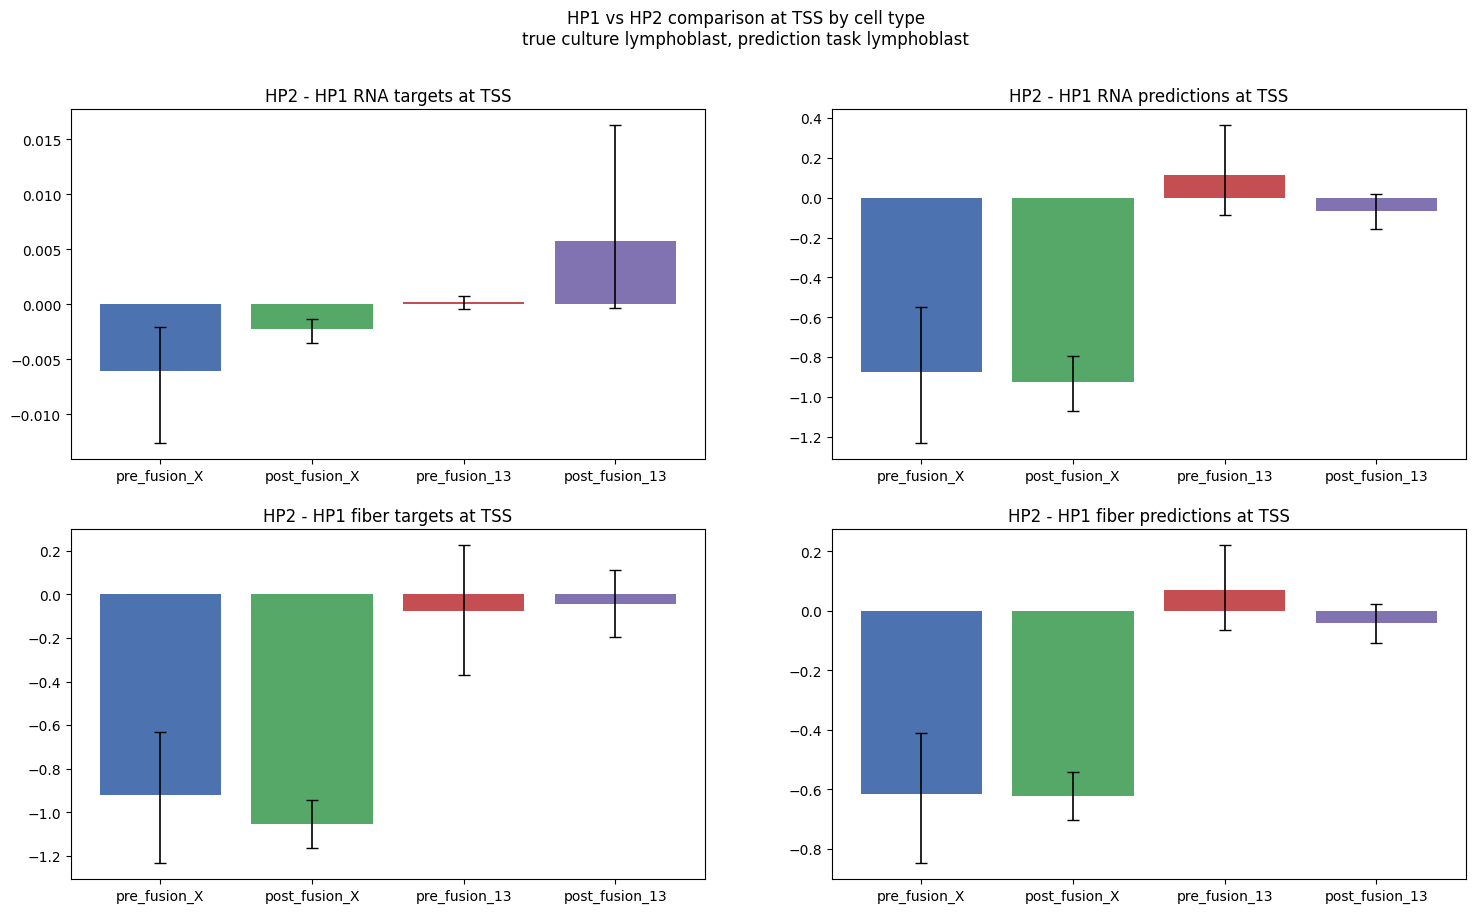

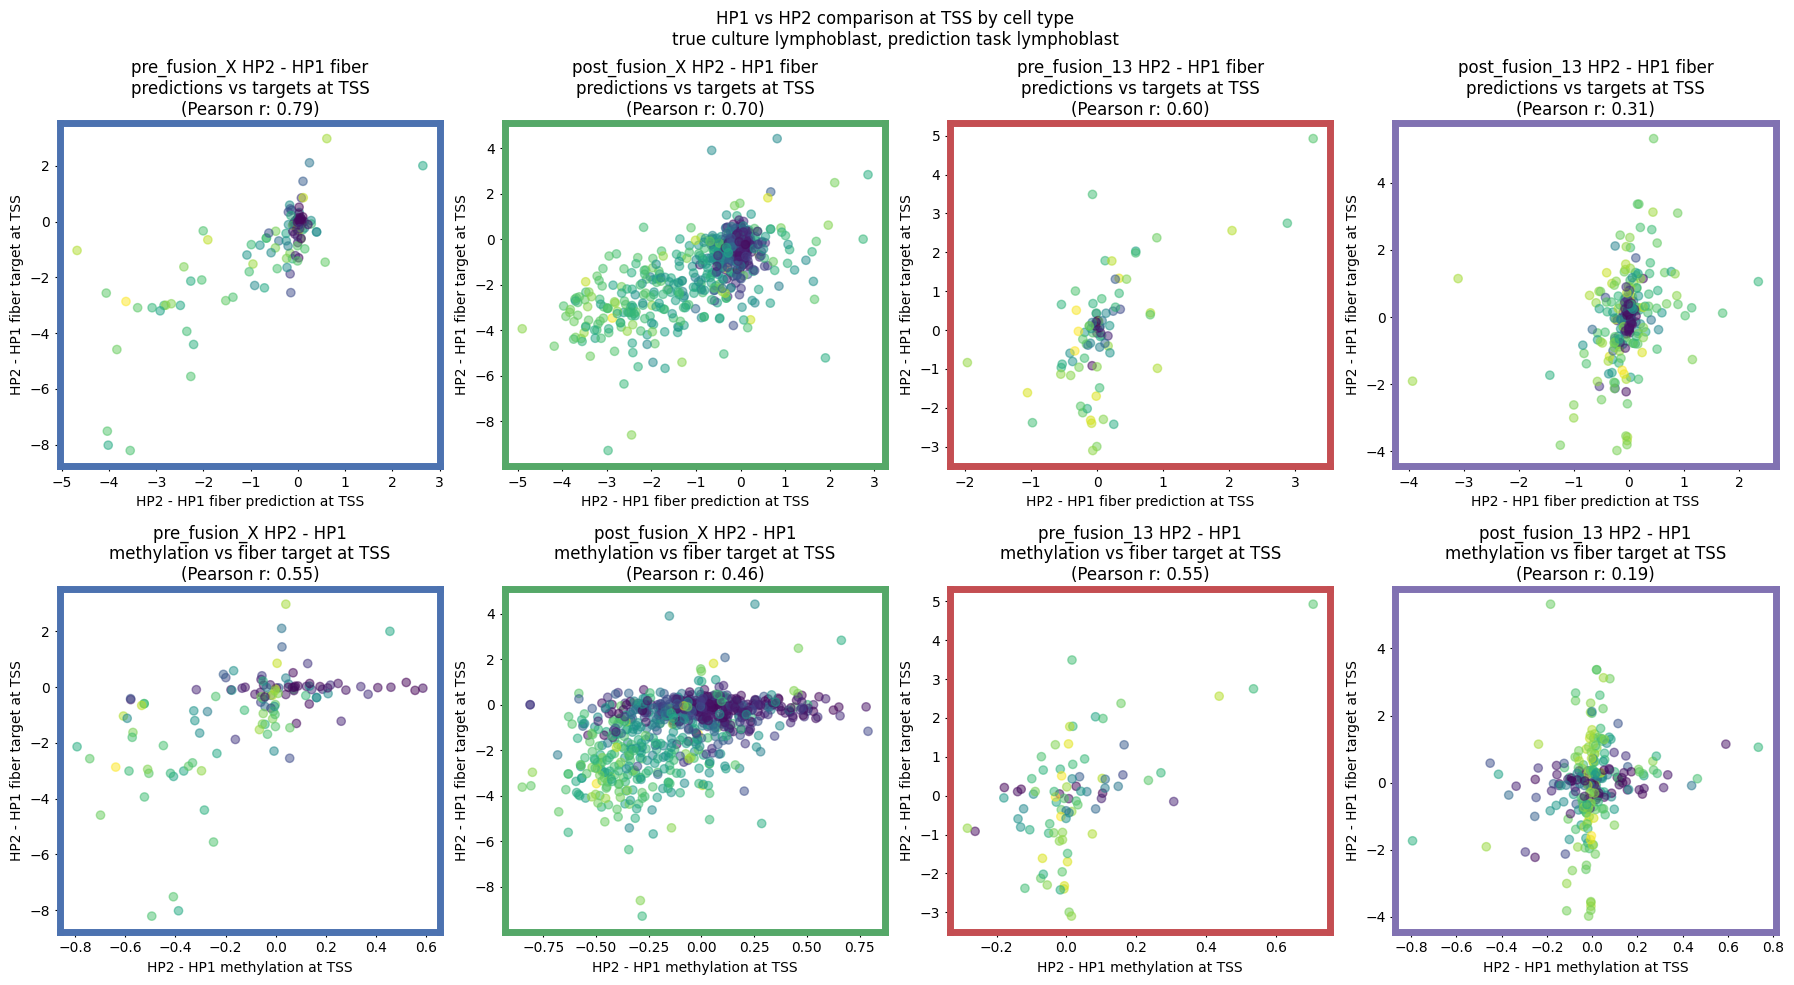

In [11]:
for cell_culture in gm_hp1_tss_rna_by_section.keys():
    for celltype in channels_dict.keys():
        colors = [
            "#4C72B0",
            "#55A868",
            "#C44E52",
            "#8172B2",
        ]
        fig, axs = plt.subplots(2, 2, figsize=(18, 10))
        fig.suptitle(f"HP1 vs HP2 comparison at TSS by cell type\ntrue culture {cell_culture}, prediction task {celltype}")

        plot_bootstrap_bar(axs[0,0], gm_hp1_tss_rna_by_section[cell_culture][celltype],
                        gm_hp2_tss_rna_by_section[cell_culture][celltype], colors,
                        "HP2 - HP1 RNA targets at TSS")
        plot_bootstrap_bar(axs[0,1], gm_hp1_tss_pred_rna_by_section[cell_culture][celltype],
                        gm_hp2_tss_pred_rna_by_section[cell_culture][celltype], colors,
                        "HP2 - HP1 RNA predictions at TSS")
        plot_bootstrap_bar(axs[1,0], gm_hp1_tss_fiber_by_section[cell_culture][celltype],
                        gm_hp2_tss_fiber_by_section[cell_culture][celltype], colors,
                        "HP2 - HP1 fiber targets at TSS")
        plot_bootstrap_bar(axs[1,1], gm_hp1_tss_pred_fiber_by_section[cell_culture][celltype],
                        gm_hp2_tss_pred_fiber_by_section[cell_culture][celltype], colors,
                        "HP2 - HP1 fiber predictions at TSS")
        fig2, axs2 = plt.subplots(2,4,figsize=(18,10))
        fig2.suptitle(f"HP1 vs HP2 comparison at TSS by cell type\ntrue culture {cell_culture}, prediction task {celltype}")
        for section_idx, section in enumerate(gm_hp1_tss_rna_by_section[cell_culture][celltype].keys()):
            # axs2[section_idx//2,section_idx%2].scatter(
            #     np.array(hp2_tss_pred_rna_by_section[section]) - np.array(hp1_tss_pred_rna_by_section[section]),
            #     np.array(hp2_tss_rna_by_section[section]) - np.array(hp1_tss_rna_by_section[section]),
            #     alpha=0.5,
            # )
            # axs2[section_idx//2,section_idx%2].set_title(f"{section} HP2 - HP1 RNA predictions vs targets at TSS")
            # axs2[section_idx//2,section_idx%2].set_xlabel("HP2 - HP1 RNA prediction at TSS")
            # axs2[section_idx//2,section_idx%2].set_ylabel("HP2 - HP1 RNA target at TSS")
            axs2[section_idx//4,section_idx%4].scatter(
                np.array(gm_hp2_tss_pred_fiber_by_section[cell_culture][celltype][section]) - np.array(gm_hp1_tss_pred_fiber_by_section[cell_culture][celltype][section]),
                np.array(gm_hp2_tss_fiber_by_section[cell_culture][celltype][section]) - np.array(gm_hp1_tss_fiber_by_section[cell_culture][celltype][section]),
                c=gm_hp1_tss_conditional_rep_by_section[cell_culture][celltype][section],
                alpha=0.5,
            )
            for spine in axs2[section_idx//4,section_idx%4].spines.values():
                spine.set_edgecolor(colors[section_idx])
                spine.set_linewidth(5)  # optional thickness
            pearsonr_differential = pearsonr(
                np.array(gm_hp2_tss_pred_fiber_by_section[cell_culture][celltype][section]) - np.array(gm_hp1_tss_pred_fiber_by_section[cell_culture][celltype][section]),
                np.array(gm_hp2_tss_fiber_by_section[cell_culture][celltype][section]) - np.array(gm_hp1_tss_fiber_by_section[cell_culture][celltype][section]),
            )
            axs2[section_idx//4,section_idx%4].set_title(f"{section} HP2 - HP1 fiber\npredictions vs targets at TSS\n(Pearson r: {pearsonr_differential[0]:.2f})")
            axs2[section_idx//4,section_idx%4].set_xlabel("HP2 - HP1 fiber prediction at TSS")
            axs2[section_idx//4,section_idx%4].set_ylabel("HP2 - HP1 fiber target at TSS")
            axs2[section_idx//4+1,section_idx%4].scatter(
                np.array(gm_hp1_tss_methylation_by_section[cell_culture][celltype][section]) - np.array(gm_hp2_tss_methylation_by_section[cell_culture][celltype][section]),
                np.array(gm_hp2_tss_fiber_by_section[cell_culture][celltype][section]) - np.array(gm_hp1_tss_fiber_by_section[cell_culture][celltype][section]),
                c=gm_hp1_tss_conditional_rep_by_section[cell_culture][celltype][section],
                alpha=0.5,
            )
            for spine in axs2[section_idx//4+1,section_idx%4].spines.values():
                spine.set_edgecolor(colors[section_idx])
                spine.set_linewidth(5)
            pearsonr_differential_methylation = pearsonr(
                np.array(gm_hp1_tss_methylation_by_section[cell_culture][celltype][section]) - np.array(gm_hp2_tss_methylation_by_section[cell_culture][celltype][section]),
                np.array(gm_hp2_tss_fiber_by_section[cell_culture][celltype][section]) - np.array(gm_hp1_tss_fiber_by_section[cell_culture][celltype][section]),
            )
            axs2[section_idx//4+1,section_idx%4].set_title(f"{section} HP2 - HP1\nmethylation vs fiber target at TSS\n(Pearson r: {pearsonr_differential_methylation[0]:.2f})")
            axs2[section_idx//4+1,section_idx%4].set_xlabel("HP2 - HP1 methylation at TSS")
            axs2[section_idx//4+1,section_idx%4].set_ylabel("HP2 - HP1 fiber target at TSS")
        plt.tight_layout()
        plt.show()

In [5]:
udn_hp1_scale = 1e9 / np.mean([load_total_counts(udn_hp1_fiber_file) for udn_hp1_fiber_file in udn_hp1_fibroblast_fiber_files])
udn_hp2_scale = 1e9 / np.mean([load_total_counts(udn_hp2_fiber_file) for udn_hp2_fiber_file in udn_hp2_fibroblast_fiber_files])
gm_hp1_scale = 1e9 / np.mean([load_total_counts(gm_hp1_fiber_file) for gm_hp1_fiber_file in gm_hp1_fiber_files])
gm_hp2_scale = 1e9 / np.mean([load_total_counts(gm_hp2_fiber_file) for gm_hp2_fiber_file in gm_hp2_fiber_files])
print(udn_hp1_scale, udn_hp2_scale, gm_hp1_scale, gm_hp2_scale)

0.9409367385046022 0.8990565430999907 1.272670384592476 1.2588208773131306


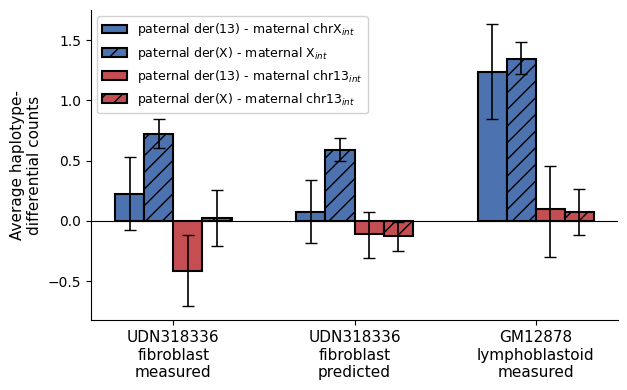

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Bootstrap helper ──────────────────────────────────────────────────────
def bootstrap_mean_diff_ci(v1, v2, n_boot=1000, ci=95):
    """Bootstrap CI for mean(v2) - mean(v1), resampling paired sites."""
    v1, v2 = np.array(v1), np.array(v2)
    n = len(v1)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        idx = np.random.randint(0, n, size=n)
        diffs[i] = np.mean(v1[idx]) - np.mean(v2[idx])
    lo = np.percentile(diffs, (100 - ci) / 2)
    hi = np.percentile(diffs, 100 - (100 - ci) / 2)
    return np.mean(v1) - np.mean(v2), lo, hi


# ── Segment style config ──────────────────────────────────────────────────
# Edit these dicts to control per-segment appearance.
# Keys should match your section names in the data dicts.

DEFAULT_SEGMENT_STYLES = {
    "pre_fusion_X": dict(
        color="#4C72B0",
        hatch="",
        edgecolor="black",
        label="pre-fusion X",
    ),
    "post_fusion_X": dict(
        color="#4C72B0",
        hatch="//",
        edgecolor="black",
        label="post-fusion X",
    ),
    "pre_fusion_13": dict(
        color="#C44E52",
        hatch="",
        edgecolor="black",
        label="pre-fusion 13",
    ),
    "post_fusion_13": dict(
        color="#C44E52",
        hatch="//",
        edgecolor="black",
        label="post-fusion 13",
    ),
}


# ── Grouped bar plot ──────────────────────────────────────────────────────
def plot_grouped_fiber_bars(
    # UDN data dicts: section -> array of per-TSS values
    udn_hp1_fiber,
    udn_hp2_fiber,
    udn_hp1_pred_fiber,
    udn_hp2_pred_fiber,
    # GM12878 data dicts
    gm_hp1_fiber,
    gm_hp2_fiber,
    # scaling
    scale_factors=None,
    # Style
    segment_styles=None,
    group_labels=None,
    title="",
    ylabel="",
    figsize=(12, 5),
    bar_width=0.18,
    group_gap=0.4,
    error_kw=None,
    crop=None,
):
    """
    Groups are measurement types:
      1. UDN measured   (HP2 - HP1 fiber targets)
      2. UDN predicted  (HP2 - HP1 fiber predictions)
      3. GM12878 measured (HP2 - HP1 fiber targets)

    Bars within each group are colored/hatched by chromosomal segment.
    """
    if scale_factors is None:
        scale_factors = [(1.0, 1.0)] * 3  # (hp1_scale, hp2_scale) per group

    if segment_styles is None:
        segment_styles = DEFAULT_SEGMENT_STYLES
    if group_labels is None:
        group_labels = ["UDN318336\nfibroblast\nmeasured", "UDN318336\nfibroblast\npredicted", "GM12878\nlymphoblastoid\nmeasured"]
    if error_kw is None:
        error_kw = dict(lw=1.2, color="black", capsize=4)

    sections = list(udn_hp1_fiber.keys())
    n_sections = len(sections)
    n_groups = 3

    # Precompute all bootstrap results: [group_idx][section] -> (mean, lo, hi)
    group_pairs = [
        (udn_hp1_fiber, udn_hp2_fiber),
        (udn_hp1_pred_fiber, udn_hp2_pred_fiber),
        (gm_hp1_fiber, gm_hp2_fiber),
    ]
    if crop is None:
        crop = {}
    group_data = [
        {sec: bootstrap_mean_diff_ci(
            (np.array(hp1[sec]) * sf[0])[crop.get(sec, (0,0))[0] : len(hp1[sec]) - crop.get(sec, (0,0))[1] or None],
            (np.array(hp2[sec]) * sf[1])[crop.get(sec, (0,0))[0] : len(hp2[sec]) - crop.get(sec, (0,0))[1] or None])
        for sec in sections}
        for (hp1, hp2), sf in zip(group_pairs, scale_factors)
    ]

    fig, ax = plt.subplots(figsize=figsize)

    group_centers = []
    for g_idx in range(n_groups):
        group_left = g_idx * (n_sections * bar_width + group_gap)
        center = group_left + (n_sections - 1) * bar_width / 2
        group_centers.append(center)

        for s_idx, sec in enumerate(sections):
            x = group_left + s_idx * bar_width
            m, lo, hi = group_data[g_idx][sec]
            style = segment_styles.get(sec, {})

            ax.bar(
                x, m, bar_width,
                color=style.get("color", "#999999"),
                hatch=style.get("hatch", ""),
                edgecolor=style.get("edgecolor", "black"),
                linewidth=style.get("linewidth", 1.5),
                yerr=[[m - lo], [hi - m]],
                error_kw=error_kw,
            )

    # x-axis: group labels
    ax.set_xticks(group_centers)
    ax.set_xticklabels(group_labels, fontsize=11)
    ax.axhline(0, color="black", linewidth=0.8, zorder=0)

    # Legend: one entry per segment
    seen = {}
    legend_handles = []
    for sec in sections:
        style = segment_styles.get(sec, {})
        key = (style.get("color"), style.get("hatch", ""), style.get("label", sec))
        if key not in seen:
            seen[key] = True
            legend_handles.append(
                mpatches.Patch(
                    facecolor=style.get("color", "#999999"),
                    hatch=style.get("hatch", ""),
                    edgecolor=style.get("edgecolor", "black"),
                    linewidth=style.get("linewidth", 1.5),
                    label=style.get("label", sec),
                )
            )
    ax.legend(handles=legend_handles, loc="best", framealpha=0.9, fontsize=9)

    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    return fig, ax


# ── Usage ─────────────────────────────────────────────────────────────────

udn_culture = "fibroblast"
gm_culture = "lymphoblast"
udn_celltype = "fibroblast"
gm_celltype = "lymphoblast"

# Customize segment styles here:
my_segment_styles = {
    "pre_fusion_X": dict(
        color="#4C72B0",
        hatch="",
        edgecolor="black",
        label=r"paternal der(13) - maternal chrX$_{int}$",
    ),
    "post_fusion_X": dict(
        color="#4C72B0",
        hatch="//",
        edgecolor="black",
        label=r"paternal der(X) - maternal X$_{int}$",
    ),
    "pre_fusion_13": dict(
        color="#C44E52",
        hatch="",
        edgecolor="black",
        label=r"paternal der(13) - maternal chr13$_{int}$",
    ),
    "post_fusion_13": dict(
        color="#C44E52",
        hatch="//",
        edgecolor="black",
        label=r"paternal der(X) - maternal chr13$_{int}$",
    ),
}

crop = {
    "pre_fusion_X": (0, 5),
    "post_fusion_X": (3, 0),
    "pre_fusion_13": (0, 2),
    "post_fusion_13": (1, 0),
}

fig, ax = plot_grouped_fiber_bars(
    udn_hp1_fiber=hp1_tss_fiber_by_section[udn_culture][udn_celltype],
    udn_hp2_fiber=hp2_tss_fiber_by_section[udn_culture][udn_celltype],
    udn_hp1_pred_fiber=hp1_tss_pred_fiber_by_section[udn_culture][udn_celltype],
    udn_hp2_pred_fiber=hp2_tss_pred_fiber_by_section[udn_culture][udn_celltype],
    gm_hp1_fiber=gm_hp1_tss_fiber_by_section[gm_culture][gm_celltype],
    gm_hp2_fiber=gm_hp2_tss_fiber_by_section[gm_culture][gm_celltype],
    scale_factors=[
        (udn_hp1_scale, udn_hp2_scale),
        (1.0, 1.0),
        (gm_hp1_scale, gm_hp2_scale),
        ],  # Example scaling to align GM12878 with UDN
    segment_styles=my_segment_styles,
    # title=f"HP2 − HP1 Fiber-seq at TSS\nUDN ({udn_culture}) vs GM12878 ({gm_culture})",
    figsize=(6,4),
    crop=crop,
)
ax.set_ylabel("Average haplotype-\ndifferential counts")
fig.savefig("pdfs/der13_derX_barplot.pdf", bbox_inches="tight", transparent=True, format="pdf")
plt.show()

torch.Size([297]) torch.Size([297])


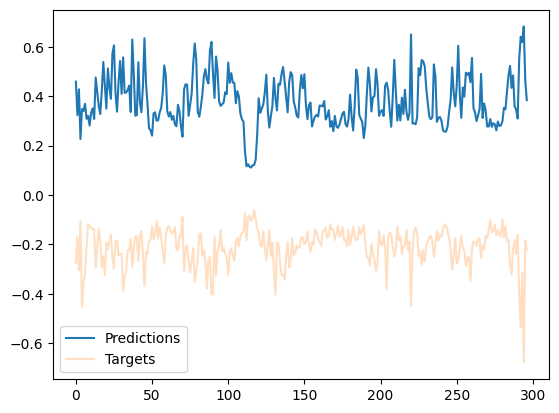

In [16]:
predictions_reshaped = 2*hp2_dict["predictions"][0, 0, :].reshape(-1, 4096).mean(axis=1)
targets_slice = hp2_dict["targets"][0, :]
targets_softclipped = torch.clamp(targets_slice, min=0, max=32) + torch.clamp(targets_slice - 32, min=0)**0.5
targets_softclipped_reshaped = targets_softclipped.reshape(-1, 4096).mean(axis=1)
print(predictions_reshaped.shape,targets_softclipped_reshaped.shape)
plt.plot(predictions_reshaped,label="Predictions")
plt.plot(-targets_softclipped_reshaped,label="Targets",alpha=0.25)
plt.legend()
plt.show()